# EDIS 8100 · Week 2 · Exploring Learning Data

### Mapping the Learning Analytics Landscape and Theoretical Lenses

*Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia*

---

We will work through this notebook together in class, in the hour after the discussion block and
the break. Nothing from it is collected and nothing in it is graded, so there is no submission to
prepare.

If Python is new to you, that is the expected starting point here. Every cell already contains
working code, and there is no expectation that you write code from scratch today or in any week of
this course. Coding skill is not what is assessed anywhere in this seminar. Your attention is
better spent on what the code is doing to the data and on what the output might mean.

Questions are welcome at any point, including questions about a single line of code. Red error
text is normal and is part of how everyone works with notebooks.

### What I hope you leave with

1. A sense of how `groupby` moves a clickstream from one grain to another, and how `merge` puts
   two tables side by side.
2. After each data step, ask: Who is still included, who is no longer included, and does that matter?
3. Learn to read a scatterplot by separating what the graph actually shows from what we might be tempted to conclude from it.
4. Use the claim ladder from feature → indicator → construct to think about the gap between what is recorded in the data and what we actually care about theoretically.
5. Recognize that choices made during data preparation, even something like changing the axis scale, can change how we interpret the data.

None of these is a coding objective!

## What an export looks like

Today the data is real and it is institutional: enrollment records and daily click
counts from a course that ran at a UK distance-teaching university, involving people who studied,
some of whom passed and many of whom left.

Real data does not arrive arranged into a lesson. In this session we will meet a sixth of the
cohort with no click recorded anywhere, activity recorded before the course started, a column with
blanks in it, a category label typed out of pattern, and two separate runs of the same course in
one file, which a careless join will fuse into one. None of that is a flaw in the download. That
is what an institutional export looks like when it arrives, and meeting it well is most of the
work.

## How to work through this notebook

- Run cells **top to bottom**. Click a cell, then press **Shift + Enter**.
- This runs on a temporary machine in the cloud, working on a copy of a published file. If
  something goes wrong, `Runtime > Restart session and run all` resolves almost everything, and it is what
  experienced people do too.
- Cells marked **Your turn** already hold a working value. You can run the whole notebook without
  editing anything and nothing will be missing.
- The section marked **Going further** near the end is optional. Please feel free to skip it today.
- The code is short. Where the attention belongs is in the interpretation prompts after each
  output.

**If you work in R, SPSS, or Stata, or have not written code before,** you might find it useful to
read the code the way you read a methods section: you are checking what was done to the data, not
memorizing syntax. Two patterns cover most of what we use. Square brackets after a table, as in
`df[df.score > 50]`, select a subset, like `subset()` or a filter. A line ending in `.mean()`,
`.sum()`, or `.value_counts()` summarizes, like `aggregate()` or a frequency table. When a line
does not make sense, please ask.

## Where this data came from

It may be useful to start where we will start with any dataset: with where it came from.

**Dataset.** The Open University Learning Analytics Dataset (OULAD), restricted to module **BBB**
and its two presentations, **2013J** and **2014J**. A *presentation* is one running of a module,
the way EDIS 8100 Fall 2026 is one running of EDIS 8100.

| | |
|---|---|
| **What** | Enrollment records, daily click counts, and assessment scores for module BBB at the UK Open University |
| **Who collected it** | The university's own teaching systems, as a by-product of running an online Virtual Learning Environment, then anonymized and published by its analytics team |
| **When** | Two presentations of the module, 2013J and 2014J |
| **License** | CC BY 4.0. Free to use, share, and adapt, with attribution |
| **Citation** | Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics dataset. *Scientific Data, 4*, 170171. |

**What it cost to get here.** Publishing student records is not a matter of uploading a folder.
Names are gone; students are integers. Calendar dates are gone; every date is a **day number
counted from the first day of the module**, which is why we are about to see negative dates. Home
addresses are gone; in their place is `imd_band`, the decile of the UK Index of Multiple
Deprivation for the small area a student lives in, an area-level measure that describes a
neighborhood and not a person. The module itself is identified only as BBB.

Each of those substitutions protects somebody and costs the analyst something. That trade is a
standing condition of the field.

**The stance we take.** The 395 Portuguese students behind Week 1 were real people, and nothing about the
ask has changed except its scale. The people in this file studied a real module, some passed, more
withdrew than most readers expect, and none of them can correct us. It is worth asking who could
be harmed by a claim before making it.

**One sentence, for when someone asks what you are working with.** *"Anonymized records from one
module of the UK Open University, 2013 and 2014, collected by the university's own teaching
systems and published by Kuzilek, Hlosta, and Zdrahal under CC BY 4.0."*

## Setup

**Run the cell below.** It downloads this week's six files from the course dataset repository. It
needs no account, no password, and no installation, and it prints what arrived.

If the runtime has no internet connection, the cell says so in plain English rather than printing
a long red error trace.

In [ ]:
# SETUP CELL. Downloads this week's data and sets the plotting defaults.
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Default matplotlib look plus a faint grid, so every chart looks the same for everyone.
plt.style.use('default')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.dpi'] = 100

BASE = 'https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/main/oulad-bbb'

FILES = {
    'student_info':         ('studentInfo.csv',         'one enrollment: who signed up, and how it ended'),
    'student_vle':          ('studentVle.csv.gz',       'one student, one resource, one day: the clickstream'),
    'student_assessment':   ('studentAssessment.csv',   'one submitted assessment: the score'),
    'assessments':          ('assessments.csv',         'one assessment: its type, due day, and weight'),
    'student_registration': ('studentRegistration.csv', 'one enrollment: when they registered, when they left'),
    'vle':                  ('vle.csv',                 'one resource in the course website'),
}

tables = {}
try:
    for key, (filename, _) in FILES.items():
        tables[key] = pd.read_csv(f'{BASE}/{filename}')
except Exception as err:
    print('=' * 74)
    print('The data did not download, so nothing below this cell will work yet.')
    print()
    print('This notebook reads six files from the course dataset repository:')
    print('    HakeoungLee/edis8100-datasets, folder oulad-bbb')
    print(f'    {BASE}')
    print()
    print('The usual cause is no internet connection in this runtime. Check your')
    print('connection, then use Runtime > Restart session and run all. If the repository')
    print('itself is unreachable, tell Dr. Lee: the link above is the one to send.')
    print()
    print(f'Technical detail, for the record: {type(err).__name__}: {err}')
    print('=' * 74)
    raise SystemExit('Download failed. The message above says what to do.') from None

student_info         = tables['student_info']
student_vle          = tables['student_vle']
student_assessment   = tables['student_assessment']
assessments          = tables['assessments']
student_registration = tables['student_registration']
vle                  = tables['vle']

print('Six files arrived from HakeoungLee/edis8100-datasets (folder oulad-bbb).')
print()
total_rows = 0
for key, (filename, grain) in FILES.items():
    df = tables[key]
    total_rows += len(df)
    print(f'  {filename:<26} {len(df):>7,} rows x {df.shape[1]:>2} cols   one row is {grain}')
print()
print(f'  {"TOTAL":<26} {total_rows:>7,} rows')
print()
print('Module:', student_info['code_module'].unique().tolist(),
      '   Presentations:', sorted(student_info['code_presentation'].unique().tolist()))
print('Real, published, CC BY 4.0 data. Kuzilek, Hlosta, and Zdrahal (2017).')

Six files arrived from HakeoungLee/edis8100-datasets (folder oulad-bbb).

  studentInfo.csv              4,529 rows x 12 cols   one row is one enrollment: who signed up, and how it ended
  studentVle.csv.gz          891,062 rows x  6 cols   one row is one student, one resource, one day: the clickstream
  studentAssessment.csv       21,783 rows x  5 cols   one row is one submitted assessment: the score
  assessments.csv                 18 rows x  6 cols   one row is one assessment: its type, due day, and weight
  studentRegistration.csv      4,529 rows x  5 cols   one row is one enrollment: when they registered, when they left
  vle.csv                        528 rows x  6 cols   one row is one resource in the course website

  TOTAL                      922,449 rows

Module: ['BBB']    Presentations: ['2013J', '2014J']
Real, published, CC BY 4.0 data. Kuzilek, Hlosta, and Zdrahal (2017).


## 1. Meet the tables

Three of those six files matter today, and they have three genuinely different origins.

- `studentVle` is a **log**. One row says: on day *d*, student *s* clicked resource *r* this many
  times. Nobody designed it to answer a research question. It is a by-product of running the
  website.
- `studentAssessment` is a **measurement**. One row per submitted assessment, produced by an
  instrument somebody built on purpose and marked by somebody trying to measure something.
- `studentInfo` is an **administrative record**. One row per enrollment, assembled by a registry
  for reasons that have nothing to do with research: funding, reporting, compliance.

Learning analytics almost always means putting those kinds of data next to each other and arguing
about what the pairing means. The **grain** of a file, meaning what one row is, is worth
establishing before anything else. Getting the grain wrong is a common way an analysis goes
quietly wrong.

**Run the cell below.**

In [ ]:
print('studentInfo: one row per ENROLLMENT (a student in a presentation)')
display(student_info.head(3))

print('studentVle: one row per STUDENT x RESOURCE x DAY')
display(student_vle.head(3))

print('studentAssessment: one row per SUBMITTED ASSESSMENT')
display(student_assessment.head(3))

print('Rows are not students. Count carefully:')
print('  studentInfo rows (enrollments) :', f'{len(student_info):,}')
print('  distinct id_student values     :', f"{student_info['id_student'].nunique():,}")
print('  studentVle rows                :', f'{len(student_vle):,}')
print('  total clicks in studentVle     :', f"{student_vle['sum_click'].sum():,}")

studentInfo: one row per ENROLLMENT (a student in a presentation)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,BBB,2013J,23632,F,East Anglian Region,A Level or Equivalent,40-50%,0-35,0,60,N,Withdrawn
1,BBB,2013J,23798,M,Wales,A Level or Equivalent,50-60%,0-35,0,60,N,Distinction
2,BBB,2013J,25629,F,Scotland,Lower Than A Level,20-30%,0-35,0,120,N,Withdrawn


studentVle: one row per STUDENT x RESOURCE x DAY


,code_module,code_presentation,id_student,id_site,date,sum_click
0,BBB,2013J,560773,704206,-23,1
1,BBB,2013J,560773,704205,-23,1
2,BBB,2013J,560773,704204,-23,1


studentAssessment: one row per SUBMITTED ASSESSMENT


,id_assessment,id_student,date_submitted,is_banked,score
0,14996,23798,18,0,90.0
1,14996,27759,18,0,61.0
2,14996,30091,24,0,80.0


Rows are not students. Count carefully:
  studentInfo rows (enrollments) : 4,529
  distinct id_student values     : 4,482
  studentVle rows                : 891,062
  total clicks in studentVle     : 3,052,400


**Let's look at the output.** Three things are worth a moment.

- What did a student have to do for a `studentVle` row to appear? What could a student do in this
  course that would leave no row at all?
- `studentInfo` has 4,529 rows and 4,482 distinct students. Before scrolling on, you might write
  down your best guess for why.
- A click log makes some questions easy to ask. It may be useful to name one question it quietly
  makes impossible.

*Connecting to the readings.* Baker and Siemens (2014) describe educational data mining and
learning analytics as two traditions that grew up around traces like these, and that handle the
gap between a recorded number and an educational idea differently. One tends to work bottom up
from the features toward automated discovery; the other tends to keep a person responsible for the
construct and for asking whether an indicator deserves the name it was given. Both moves are
available in what we are about to do.

## 2. What an export actually looks like when it arrives

Here is the part a tidy teaching file cannot teach, because a file like Week 1's arrives already
arranged: one table, one row per student, and nothing to assemble.

Four things in this download will produce a wrong answer if nobody looks. We will meet all four,
make each decision in view, and say what the decision costs. That last step is the one that is
easiest to skip.

### 2a. Two runs of the module under one name

`code_presentation` takes two values. 2013J and 2014J are two different runs of module BBB, a year
apart, with different students, different teaching staff, and, as we will see shortly, different
assessment structures.

Some students appear in **both**. They took the module, it did not go well, and they took it
again. Grouping by `id_student` alone adds those two attempts together into one imaginary person
who clicked more than anyone did.

**Run the cell below.**

In [ ]:
print('Enrollments per presentation:')
print(student_info['code_presentation'].value_counts().sort_index().to_string())
print()

n_rows     = len(student_info)
n_students = student_info['id_student'].nunique()
n_repeat   = n_rows - n_students
print(f'{n_rows:,} enrollment rows but only {n_students:,} distinct students.')
print(f'{n_repeat} students sat this module twice, once in each presentation.')
print()

example_id = 151917
print(f'Student {example_id}, both attempts:')
display(student_info[student_info['id_student'] == example_id]
        [['id_student', 'code_presentation', 'num_of_prev_attempts',
          'studied_credits', 'final_result']])

clicks_both = (student_vle[student_vle['id_student'] == example_id]
               .groupby('code_presentation')['sum_click'].sum())
print('Their clicks, kept separate:')
print(clicks_both.to_string())
print(f'Their clicks, carelessly added together: {clicks_both.sum():,}')
print()
print(f'A groupby on id_student alone reports one student with {clicks_both.sum():,} '
      'clicks who both failed and passed.')

print()
n_prev = int((student_info['num_of_prev_attempts'] > 0).sum())
dup_rows = student_info[student_info.duplicated('id_student', keep=False)]
already = int((dup_rows.loc[dup_rows['code_presentation'] == '2013J',
                            'num_of_prev_attempts'] > 0).sum())
print(f'Rows recording at least one earlier attempt at this module: {n_prev} of {len(student_info):,}')
print(f'Of the {n_repeat} people holding two rows here, the 2013J row was already a repeat for {already}.')


Enrollments per presentation:
code_presentation
2013J    2237
2014J    2292

4,529 enrollment rows but only 4,482 distinct students.
47 students sat this module twice, once in each presentation.

Student 151917, both attempts:


,id_student,code_presentation,num_of_prev_attempts,studied_credits,final_result
71,151917,2013J,3,60,Fail
2296,151917,2014J,4,60,Pass


Their clicks, kept separate:
code_presentation
2013J    909
2014J    713
Their clicks, carelessly added together: 1,622

A groupby on id_student alone reports one student with 1,622 clicks who both failed and passed.

Rows recording at least one earlier attempt at this module: 589 of 4,529
Of the 47 people holding two rows here, the 2013J row was already a repeat for 11.


**Let's look at the output.**

**The decision, out loud.** For the rest of this notebook the unit of analysis is the
**enrollment**, not the student, and the join key is the pair `(id_student, code_presentation)`.
The person above appears twice, because they had two different experiences of this course and
averaging them would misdescribe both.

**What it costs.** Across the whole file, 47 people hold two rows each, so 47 of the 4,529 rows
are somebody already counted once. For 36 of those 47 the later row is a second attempt; for the
other 11 the 2013J row was itself already a repeat, because `num_of_prev_attempts` was above zero
before this file even opens.

**What the file cannot show.** Across all 4,529 rows, 589 record at least one earlier attempt at
this module. Only 47 of those repeats appear here as a duplicated person, because the earlier
attempts happened in presentations this download does not contain. The duplication we can see is a
small part of the repeating that actually happened.

**Where the dependency matters and where it does not.** It matters whenever rows are treated as
independent people. Section 2e scopes us to a single presentation, and inside one presentation
every `id_student` appears exactly once, so the analysis that follows is clean of it. The optional
Your turn 2 pools the two years back into one number and puts it straight back in.

### 2b. Activity before the course starts

`date` in `studentVle` is a day number counted from the first day of the module, because calendar
dates were removed to protect the students. Day 0 is day one of the course.

Negative numbers are therefore not corrupt. They are people looking at the course website before
the course opens.

**Run the cell below.**

In [ ]:
d = student_vle['date']
print(f'date runs from {d.min()} to {d.max()}    (day 0 = first day of the module)')

pre = student_vle[student_vle['date'] < 0]
print(f'Rows recorded BEFORE day 0 : {len(pre):,} of {len(student_vle):,} '
      f'({100 * len(pre) / len(student_vle):.1f}%)')
print(f'Distinct students doing it : {pre["id_student"].nunique():,}')
print()

reg = student_registration['date_registration']
print(f'Registration day: earliest {reg.min():.0f}, median {reg.median():.0f}, latest {reg.max():.0f}')
print(f'Enrollments registered before day 0 : {(reg < 0).sum():,} of {len(student_registration):,}')
print(f'Enrollments with a blank registration day: {reg.isna().sum()}')

print()
print('Earliest logged day in each presentation:')
print(student_vle.groupby('code_presentation')['date'].min().to_string())


date runs from -23 to 268    (day 0 = first day of the module)
Rows recorded BEFORE day 0 : 46,884 of 891,062 (5.3%)
Distinct students doing it : 2,739

Registration day: earliest -198, median -57, latest 44
Enrollments registered before day 0 : 4,452 of 4,529
Enrollments with a blank registration day: 3

Earliest logged day in each presentation:
code_presentation
2013J   -23
2014J    -9


**Let's look at the output.**

**The decision, out loud.** We keep the pre-start clicks. Looking at the site before it opens is
engagement, arguably the most voluntary engagement in the whole file, and dropping it would
quietly penalize the students who did it.

**What it costs, and how large that cost actually is.** Activity totals now cover an unequal
window, so "total clicks" is not a rate, and comparing two students on it compares two different
amounts of opportunity. It is worth being precise about the size of that inequality, because it is
easy to overstate. The 2013J log contains no row earlier than day -23 and the 2014J log none
earlier than day -9. The website was not producing rows before then, whatever a student's
registration date said. Registration runs from 198 days early to 44 days late, but the extra
pre-start opportunity that buys is capped at about three weeks rather than six months. Your turn 1
lets you switch this decision off and see how little moves.

### 2c. A blank column, and one label typed out of pattern

`imd_band` records the deprivation decile of the small area a student lives in. It should have ten
categories, each written the same way.

**Run the cell below** and see how many there are and how they are spelled.

In [ ]:
print('imd_band, exactly as it arrived:')
print(student_info['imd_band'].value_counts(dropna=False).to_string())
print()
print(f"Distinct labels, blanks not counted : {student_info['imd_band'].nunique()}")
print(f"Rows where imd_band is blank        : {student_info['imd_band'].isna().sum()}")
print()
print('Ten deciles, ten labels. Nine of them carry a percent sign. One does not.')
print('Sorted the way pandas sorts text:')
print(sorted(student_info['imd_band'].dropna().unique().tolist()))
print()

# What happens to somebody who writes out the ten labels the sensible way?
expected = [f'{i}-{i + 10}%' for i in range(0, 100, 10)]
print('The ten labels a careful analyst would write by hand:')
print(expected)

unmatched = ~student_info['imd_band'].isin(expected)
odd_label = int((student_info['imd_band'] == '10-20').sum())
odd_people = int(student_info.loc[student_info['imd_band'] == '10-20', 'id_student'].nunique())
blank     = int(student_info['imd_band'].isna().sum())
print()
print(f'Rows that list does NOT match : {int(unmatched.sum()):,} of {len(student_info):,} '
      f'({100 * unmatched.mean():.1f}%)')
print(f'  because the band is blank   : {blank}')
print(f'  because it says "10-20"     : {odd_label}   <- one missing percent sign')
print()
print(f'Map deciles to numbers with that list and {odd_label} real enrollments, '
      f'{odd_people} real people,')
print('silently become missing, all from the same band. Nothing errors. Nothing warns you.')

imd_band, exactly as it arrived:
imd_band
0-10%      591
20-30%     566
10-20      557
30-40%     495
40-50%     474
50-60%     449
60-70%     412
70-80%     353
80-90%     335
90-100%    268
NaN         29

Distinct labels, blanks not counted : 10
Rows where imd_band is blank        : 29

Ten deciles, ten labels. Nine of them carry a percent sign. One does not.
Sorted the way pandas sorts text:
['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

The ten labels a careful analyst would write by hand:
['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

Rows that list does NOT match : 586 of 4,529 (12.9%)
  because the band is blank   : 29
  because it says "10-20"     : 557   <- one missing percent sign

Map deciles to numbers with that list and 557 real enrollments, 550 real people,
silently become missing, all from the same band. Nothing errors. Nothing warns you.


**Let's look at the output.**

**The decision, out loud.** `imd_band` is not part of today's analysis, so we will not repair it
here. It is worth seeing because this is what the problem looks like: a socioeconomic variable,
the exact variable an equity audit would reach for, arriving with a blank on 29 enrollment records
and one band typed without its percent sign.

**What it costs, if you ever do use it.** This kind of mess produces no warning, which is what
makes it worth checking for. There is no duplicate category to spot and no error to catch. The
moment those labels are converted to numbers with a hand-written list, or filtered with a
`str.endswith('%')`, the 557 enrollments in the second-most-deprived band, 550 distinct people,
drop out of the analysis and nothing in the output says so. Drop the 29 blanks on top of that and
the analysis has also removed people whose deprivation was never recorded, and "not recorded" is
rarely random either.

**What the column does and does not record.** `imd_band` is a decile of the UK Index of Multiple
Deprivation for the small area attached to a student's address at one point in time. It describes
a neighborhood, not a household and not a person. Two students in the same band may have had
entirely different circumstances, and a student's band may have changed during the module without
the file noticing. Week 3 audits a model by subgroup using this column. Reading a difference
across these bands carefully, with the group sizes, the 29 blanks, and the label problem all in
view, is the exercise there, and it is a different exercise from asking what the bands say about
the people in them.

### 2d. Enrollments with no activity at all

The clickstream can only contain students who clicked. Finding the students who did not means
starting from the roster and looking for who is **missing** from the log. This is a habit worth
keeping for the rest of the semester.

**Run the cell below.**

In [ ]:
KEY = ['id_student', 'code_presentation']

any_activity = student_vle[KEY].drop_duplicates()
roster = student_info.merge(any_activity.assign(clicked=True), on=KEY, how='left')
roster['clicked'] = roster['clicked'].fillna(False).astype(bool)

n_silent = int((~roster['clicked']).sum())
print(f'Enrollments in studentInfo        : {len(roster):,}')
print(f'Enrollments with at least 1 click : {int(roster["clicked"].sum()):,}')
print(f'Enrollments with NO clicks ever   : {n_silent:,}  '
      f'({100 * n_silent / len(roster):.1f}%, about 1 in {len(roster) / n_silent:.1f})')
print()

print('How every enrollment ended:')
print(student_info['final_result'].value_counts().to_string())
print()
print('Percent of the whole cohort:')
print((100 * student_info['final_result'].value_counts(normalize=True)).round(1).to_string())

Enrollments in studentInfo        : 4,529
Enrollments with at least 1 click : 3,791
Enrollments with NO clicks ever   : 738  (16.3%, about 1 in 6.1)

How every enrollment ended:
final_result
Pass           1868
Withdrawn      1393
Fail            912
Distinction     356

Percent of the whole cohort:
final_result
Pass           41.2
Withdrawn      30.8
Fail           20.1
Distinction     7.9


**Let's look at the output.** Those two blocks are worth reading together.

About one enrollment in six never registers a single click, and close to a third of the cohort
ends in `Withdrawn`. This is a distance-learning module with open entry, so those numbers describe
the population it enrolls rather than anything about the individuals in it. It also means the
students an early-warning system is most concerned with are the students who leave the least data
behind. That comes back shortly with a number attached.

### 2e. The scoping decision

We are going to analyze **one presentation, 2013J**, and say so every time we report a number.

Why not both? Because they are not the same course. In the table the next cell prints, 2013J was
assessed with six tutor-marked assignments and five computer-marked ones, while 2014J was assessed
with five tutor-marked assignments and no computer-marked ones at all, and the first of those five
carried a weight of zero. Both years end with an exam. Pooling the two would average two different
grading regimes and call the result a finding.

**What it costs.** We have just cut the data in half, and we give up any chance of asking whether
a pattern replicates across years. That is a real loss. The optional Your turn 2 hands 2014J back
so you can see how much the answer depends on which year you happened to pick.

**Run the cell below.**

In [ ]:
PRESENTATION = '2013J'

print('Assessment structure, side by side:')
display(assessments.pivot_table(index='assessment_type', columns='code_presentation',
                                values='id_assessment', aggfunc='count')
                   .fillna(0).astype(int))

print('Every assessment, its due day (day number), and its weight:')
display(assessments.sort_values(['code_presentation', 'date'])
        [['code_presentation', 'assessment_type', 'date', 'weight']]
        .reset_index(drop=True))

enroll  = student_info[student_info['code_presentation'] == PRESENTATION].copy()
vle_log = student_vle[student_vle['code_presentation'] == PRESENTATION].copy()

print()
print(f'Scoped to {PRESENTATION}:')
print(f'  enrollments      : {len(enroll):,}')
print(f'  clickstream rows : {len(vle_log):,}')
print(f'  total clicks     : {vle_log["sum_click"].sum():,}')
print(f'  day range        : {vle_log["date"].min()} to {vle_log["date"].max()}')

Assessment structure, side by side:


code_presentation,2013J,2014J
assessment_type,,
CMA,5,0
Exam,1,1
TMA,6,5


Every assessment, its due day (day number), and its weight:


,code_presentation,assessment_type,date,weight
0,2013J,TMA,19.0,5.0
1,2013J,TMA,47.0,18.0
2,2013J,CMA,54.0,1.0
3,2013J,CMA,96.0,1.0
4,2013J,TMA,96.0,18.0
5,2013J,CMA,131.0,1.0
6,2013J,TMA,131.0,18.0
7,2013J,CMA,166.0,1.0
8,2013J,TMA,166.0,18.0
9,2013J,CMA,208.0,1.0



Scoped to 2013J:
  enrollments      : 2,237
  clickstream rows : 452,638
  total clicks     : 1,378,656
  day range        : -23 to 268


## 3. Aggregating with `groupby`

The clickstream is at the wrong grain for almost any question we care about. We think in students;
the file is recorded in student-resource-days. `groupby` is the tool that moves between grains.

`vle_log.groupby('id_student')` says: *split the table into one group per student.* Then we say
what to compute on each group. Two things at once here:

- `sum_click` **summed**, which is total clicks: how much.
- `date` counted for **distinct** values, which is active days: how spread out.

Those are two different ideas about activity, and they will not always agree.

**Run the cell below.**

In [ ]:
activity = (
    vle_log.groupby('id_student')
           .agg(total_clicks=('sum_click', 'sum'),
                active_days=('date', 'nunique'))
           .reset_index()
)

print(f'activity now has one row per student who clicked: {activity.shape[0]:,} rows')
display(activity.head())

print('Total clicks per student:')
print(activity['total_clicks'].describe().round(1).to_string())
print()
print(f"median  {activity['total_clicks'].median():,.0f} clicks")
print(f"maximum {activity['total_clicks'].max():,.0f} clicks")
print(f"The busiest student generated "
      f"{activity['total_clicks'].max() / activity['total_clicks'].median():.0f} times the median.")
print()
print(f'Enrollments in the roster          : {len(enroll):,}')
print(f'Students in the activity table     : {len(activity):,}')
print(f'Enrollments the groupby cannot see : {len(enroll) - len(activity):,}')
print('A groupby can only tell you about people who left rows. It has no way to')
print('mention the ones who did not, so you have to remember them yourself.')

activity now has one row per student who clicked: 1,870 rows


,id_student,total_clicks,active_days
0,23798,590,77
1,27759,366,46
2,30091,1332,64
3,31014,531,47
4,31849,1179,80


Total clicks per student:
count     1870.0
mean       737.2
std       1289.5
min          1.0
25%        148.2
50%        386.0
75%        817.2
max      16440.0

median  386 clicks
maximum 16,440 clicks
The busiest student generated 43 times the median.

Enrollments in the roster          : 2,237
Students in the activity table     : 1,870
Enrollments the groupby cannot see : 367
A groupby can only tell you about people who left rows. It has no way to
mention the ones who did not, so you have to remember them yourself.


**Let's look at the output.** The median student generated a few hundred clicks; the busiest
generated over sixteen thousand. That gap is not a data error. It is the ordinary shape of
behavioral trace data: **heavy tailed**, meaning a small number of people account for a large
share of the total.

The next cell draws two histograms side by side. The left one plots clicks as they are. The right
one plots the same students on a **log scale**, where each step along the axis is a multiplication
rather than an addition, so 10, 100, and 1,000 sit at even intervals. The people and the clicks
are the same, and only the axis differs.

It is worth remembering what the right panel looks like. Later in the notebook that choice of axis
changes a headline number by a factor of nearly two.

**Run the cell below.**

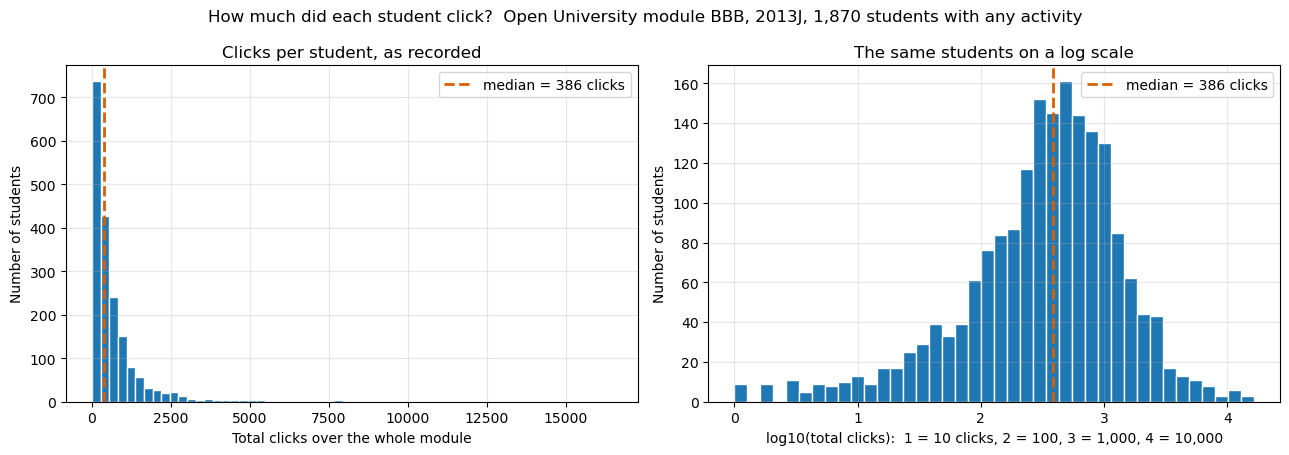

Not on either chart: 367 enrollments with no recorded clicks.
You cannot take the log of zero, so the log panel has no place to put a count of zero.
Neither panel can say whether those enrollments studied off the platform, never
opened it, or opened it in a way this log does not record.


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

med = activity['total_clicks'].median()

ax1.hist(activity['total_clicks'], bins=60, color='#1f77b4', edgecolor='white')
ax1.axvline(med, color='#d95f02', linestyle='--', linewidth=2,
            label=f'median = {med:,.0f} clicks')
ax1.set_title('Clicks per student, as recorded')
ax1.set_xlabel('Total clicks over the whole module')
ax1.set_ylabel('Number of students')
ax1.legend()

ax2.hist(np.log10(activity['total_clicks']), bins=40, color='#1f77b4', edgecolor='white')
ax2.axvline(np.log10(med), color='#d95f02', linestyle='--', linewidth=2,
            label=f'median = {med:,.0f} clicks')
ax2.set_title('The same students on a log scale')
ax2.set_xlabel('log10(total clicks):  1 = 10 clicks, 2 = 100, 3 = 1,000, 4 = 10,000')
ax2.set_ylabel('Number of students')
ax2.legend()

fig.suptitle(f'How much did each student click?  Open University module BBB, {PRESENTATION}, '
             f'{len(activity):,} students with any activity', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Not on either chart: {len(enroll) - len(activity):,} enrollments with no recorded clicks.')
print('You cannot take the log of zero, so the log panel has no place to put a count of zero.')
print('Neither panel can say whether those enrollments studied off the platform, never')
print('opened it, or opened it in a way this log does not record.')

### Let's discuss

1. The tail on the right of the first panel is behavior that somebody actually produced. It may
   be useful to describe two different students who could have produced a count out there, one
   whose count you would read as good news and one whose count you would read as a warning sign.
   What would you need to know to tell them apart?
2. The two panels contain identical information. Which one would you put before a program
   director, and what might each one lead them to believe?
3. The line printed underneath the charts is worth a moment. Some enrolled students appear on
   neither panel. How would you report a median click count when a sixth of the cohort has been
   left out of it?

### 3b. The enrollments with no recorded activity

These are not a rounding error and they are not spread evenly across the cohort. We cannot say
what these people did, because this file records clicks on one website and nothing else. What we
can do is compare them against the one column that says how each enrollment ended.

The next chart is a fact about the **record**, not about the people in it. "No recorded clicks" is
a statement about what the virtual learning environment logged, and these were adults studying at
a distance, most of them alongside paid employment.

**Run the cell below.**

,enrollments,clicked,never_clicked,pct_never_clicked
final_result,,,,
Distinction,176,176,0,0.0
Pass,896,896,0,0.0
Fail,521,472,49,9.4
Withdrawn,644,326,318,49.4


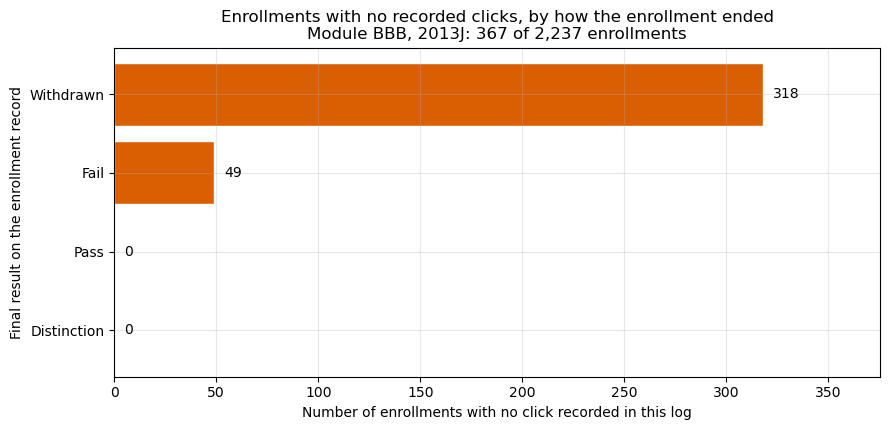

Of the 644 withdrawn enrollments, 318 (49.4%) have no click recorded.
Of the 896 passes and 176 distinctions, 0 did.


In [ ]:
enroll_flagged = enroll.merge(activity[['id_student']].assign(clicked=True),
                              on='id_student', how='left')
enroll_flagged['clicked'] = enroll_flagged['clicked'].fillna(False).astype(bool)

silent = enroll_flagged[~enroll_flagged['clicked']]
order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']

summary = (enroll_flagged.groupby('final_result')['clicked']
           .agg(enrollments='size', clicked='sum')
           .reindex(order))
summary['never_clicked'] = summary['enrollments'] - summary['clicked']
summary['pct_never_clicked'] = (100 * summary['never_clicked'] / summary['enrollments']).round(1)
display(summary)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(order, summary['never_clicked'].values, color='#d95f02', edgecolor='white')
for i, v in enumerate(summary['never_clicked'].values):
    ax.text(v + 5, i, f'{v:,}', va='center', fontsize=10)
ax.set_title('Enrollments with no recorded clicks, by how the enrollment ended\n'
             f'Module BBB, {PRESENTATION}: {len(silent):,} of {len(enroll):,} enrollments')
ax.set_xlabel('Number of enrollments with no click recorded in this log')
ax.set_ylabel('Final result on the enrollment record')
ax.set_xlim(0, max(summary['never_clicked'].max() * 1.18, 10))
plt.tight_layout()
plt.show()

print(f'Of the {int(summary.loc["Withdrawn", "enrollments"]):,} withdrawn enrollments, '
      f'{int(summary.loc["Withdrawn", "never_clicked"]):,} '
      f'({summary.loc["Withdrawn", "pct_never_clicked"]:.1f}%) have no click recorded.')
print(f'Of the {int(summary.loc["Pass", "enrollments"]):,} passes and '
      f'{int(summary.loc["Distinction", "enrollments"]):,} distinctions, '
      f'{int(summary.loc["Pass", "never_clicked"] + summary.loc["Distinction", "never_clicked"])} did.')

**Let's look at the output.** Of the 644 withdrawn enrollments in 2013J, 318 have no click
recorded at all. Of the 896 passes and 176 distinctions, none do.

It may help to keep three things separate here, and this distinction runs through the whole
semester:

| | |
|---|---|
| **What the data directly show** | 367 of the 2,237 enrollments in 2013J have no row in the clickstream. 318 of those ended in `Withdrawn`, which is 49.4 percent of the 644 withdrawals. No enrollment ending in `Pass` or `Distinction` is missing from the log. |
| **A plausible interpretation** | Some of these enrollments may represent people who registered and never began, and others may represent people who studied in ways this log does not record. |
| **What this file cannot establish** | Which of those it is for any given enrollment, since the file holds no record of study away from the platform, of when someone stopped, or of why. |

### Let's discuss

1. Nearly half of the withdrawn enrollments have no click recorded. One way into that is to work
   down three levels before reaching for an explanation about a person. **The instrument:** what
   would somebody have to do for a row to appear here, and what kinds of studying leave no row at
   all? **The setting:** what does an open-entry distance university's registration calendar and
   fee-refund window make likely in the first weeks of a module? **The circumstances:** these are
   adults at a distance university, most of whom study alongside paid employment, which is a fact
   about the Open University's population rather than a column in this file, and who registered a
   median of about eight weeks before a course that starts in October. If a candidate about the
   student still seems necessary after those three, it is worth writing that one too, and then
   noticing how many of the four are about something other than the student.
2. An early-warning system reads the clickstream. What does it know about these enrollments on day
   14, and what does it only appear to know?
3. Correlating activity with achievement needs students who have both. Every enrollment on this
   chart has neither. Before scrolling on, you might predict which final results are about to
   disappear from the analysis, and whether the finding that survives is a finding about the
   course or a finding about the people who stayed.

## 4. The claim ladder: feature, indicator, construct

This is the idea the rest of the semester depends on, and we are naming it in Week 2 so that we
can point back at it in Week 3, Week 6, and Week 7.

`total_clicks` is a number. The moment anyone says a sentence about it, they have climbed a
ladder, and most arguments in learning analytics are really arguments about which rung somebody is
standing on.

| Rung | What it is | Today's example | How much argument it needs |
|---|---|---|---|
| **Feature** | Something the system recorded that you can count without anyone objecting. | `total_clicks = 909` for student 151917 in 2013J. | Almost none. It is arithmetic. |
| **Indicator** | A feature somebody has **argued** stands in for something educational. | "Total clicks is an indicator of how engaged a student is with the module." | A lot. This is where the work is. |
| **Construct** | The thing you actually care about. Theory defines it. No column contains it. | Engagement. Self-regulated learning. Understanding. | It has a literature, and the literature disagrees. |

There is a rung below the ladder, and an institutional export is where you feel it. Before a
number is even a feature, somebody had to decide it existed: that a page load counts as a click,
that a click before day 0 counts at all, that a student who never appears in the log is a person
rather than an absence. **The recording decision sits below the feature, at the bottom of the
ladder.**

**A habit worth keeping for the rest of the course:** when you make a claim, say which rung it is
standing on. "Student 151917 generated 909 clicks in 2013J" is a feature claim and it is free.
"Student 151917 was disengaged" is a construct claim and it needs evidence.

*Connecting to the readings.* Nathan and Sawyer (2014) describe learning as deep conceptual
understanding built through activity in context, an account that declines to let learning be
defined by whatever happens to be easy to capture. None of the constructs they discuss sits in a
CSV column, and no quantity of clicks adds up to one. Baker and Siemens (2014) are useful
alongside them for naming which move you are making when you climb from a feature to an indicator.

### A line to write now

The cell below is a text cell, so you can double-click it and type in it. Three sentences to
finish, whenever you have a minute:

- The feature I have is ...
- I am proposing to treat it as an indicator of ...
- The construct I actually care about is ..., and one thing this feature will miss about it is ...

*(Your answer here. Double-click this cell to type in it.)*

- The feature I have is
- I am proposing to treat it as an indicator of
- The construct I actually care about is

## 5. The other table, then the join

Putting activity next to achievement needs achievement at the same grain: one number per student.

`studentAssessment` has no `code_presentation` column. It only knows `id_assessment`. So the first
move is to look each assessment up in the `assessments` table, where the presentation, the type,
the due day, and the weight live. That is what a **lookup join** is for, and skipping it is how
the two presentations get fused.

Three judgment calls are made in the next few lines, and all three are worth being able to
explain:

1. We keep the assessments with a **recorded score** and drop the handful with a blank score,
   rather than treating a blank as a zero. A blank could be an ungraded submission or an
   administrative gap; a zero is a claim that the student failed.
2. We take the **unweighted mean** of a student's scores. The real module weighted them: one
   tutor-marked assignment counted 5 percent, five counted 18 percent each, and the five
   computer-marked ones counted 1 percent apiece. An unweighted mean is simpler, and wrong in a
   specific, statable way. The optional section in Going further states it and measures it.
3. The **final exam is not in this file at all**. The single highest-stakes measurement in the
   module, weighted 100, has no submission rows anywhere. Every claim we make today is about
   coursework rather than final attainment.

**Run the cell below.**

In [ ]:
# Step 1: attach the presentation, type, due day, and weight to every submission.
submissions = student_assessment.merge(
    assessments[['id_assessment', 'code_presentation', 'assessment_type', 'date', 'weight']],
    on='id_assessment', how='left'
)
print(f'Submissions after the lookup join: {len(submissions):,}')
print('Submissions that failed to match an assessment: '
      f"{submissions['code_presentation'].isna().sum()}")
print()

subs = submissions[submissions['code_presentation'] == PRESENTATION].copy()
print(f'{PRESENTATION} submissions: {len(subs):,}')
print('By assessment type:')
print(subs['assessment_type'].value_counts().to_string())
print()
print('Assessment types defined for this presentation:',
      assessments[assessments['code_presentation'] == PRESENTATION]['assessment_type'].tolist())
print('One of them has no submissions anywhere in the file.')
print()

n_blank = int(subs['score'].isna().sum())
print(f'Submissions with a blank score: {n_blank}   (dropped, not zeroed)')
subs = subs.dropna(subset=['score'])

achievement = (
    subs.groupby('id_student')
        .agg(mean_score=('score', 'mean'),
             n_submissions=('score', 'size'))
        .reset_index()
)
print(f'Students with at least one scored submission: {len(achievement):,}')
display(achievement.head())
print('Scores across this presentation: mean %.1f, sd %.1f'
      % (subs['score'].mean(), subs['score'].std()))

Submissions after the lookup join: 21,783
Submissions that failed to match an assessment: 0

2013J submissions: 14,375
By assessment type:
assessment_type
TMA    7959
CMA    6416

Assessment types defined for this presentation: ['CMA', 'CMA', 'CMA', 'CMA', 'CMA', 'TMA', 'TMA', 'TMA', 'TMA', 'TMA', 'TMA', 'Exam']
One of them has no submissions anywhere in the file.

Submissions with a blank score: 10   (dropped, not zeroed)
Students with at least one scored submission: 1,710


,id_student,mean_score,n_submissions
0,23798,93.909091,11
1,27759,76.090909,11
2,30091,88.000000,10
3,31014,90.000000,5
4,31849,78.000000,11


Scores across this presentation: mean 78.9, sd 17.2


### 5b. `merge`, and an honest count of who left

`merge` lines up two tables by the columns they share. `how='inner'` keeps only the students
present in **both**, which is the right join for a scatterplot and the point at which students
quietly disappear from an analysis.

So we count before, count after, and then ask the question that is easiest to skip: **who left,
and were they a random sample?**

**Run the cell below.**

activity rows    (clicked at least once)   : 1,870
achievement rows (submitted at least once) : 1,710
panel rows       (did both)                : 1,697

  clicked but never submitted a score : 173
  submitted but no click recorded     : 13
  in the roster, in neither table     : 354

Started from 2,237 enrollments. Analyzing 1,697. Set aside 540 (24.1%).



,in the roster,in our panel,set aside,roster %,panel %
final_result,,,,,
Distinction,176,176,0,7.9,10.4
Pass,896,896,0,40.1,52.8
Fail,521,422,99,23.3,24.9
Withdrawn,644,203,441,28.8,12.0


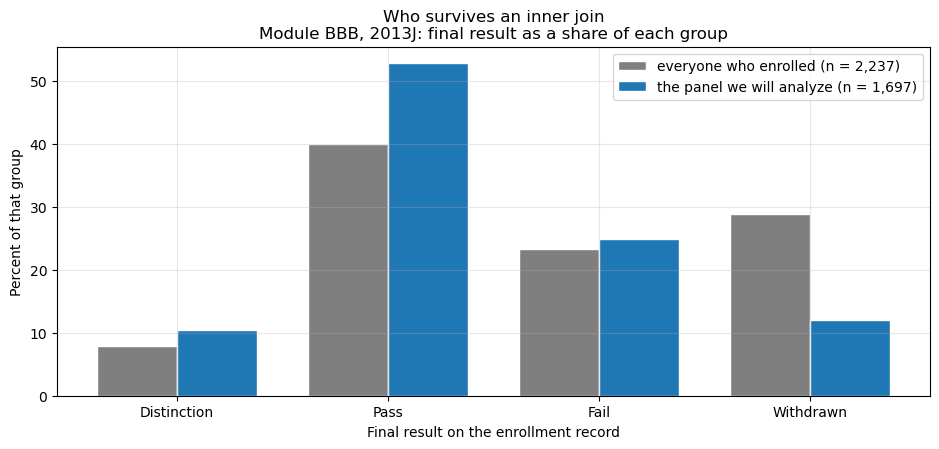

Withdrawn is 28.8% of the cohort and 12.0% of our panel.
Of the 540 enrollments we set aside: 441 withdrew, 99 failed, 0 passed.


In [ ]:
panel = activity.merge(achievement, on='id_student', how='inner')
panel = panel.merge(enroll[['id_student', 'final_result']], on='id_student', how='left')

only_clicked   = len(activity) - len(panel)
only_submitted = len(achievement) - len(panel)
neither        = len(enroll) - len(panel) - only_clicked - only_submitted

print(f'activity rows    (clicked at least once)   : {len(activity):,}')
print(f'achievement rows (submitted at least once) : {len(achievement):,}')
print(f'panel rows       (did both)                : {len(panel):,}')
print()
print(f'  clicked but never submitted a score : {only_clicked:,}')
print(f'  submitted but no click recorded     : {only_submitted:,}')
print(f'  in the roster, in neither table     : {neither:,}')
print()
dropped = len(enroll) - len(panel)
print(f'Started from {len(enroll):,} enrollments. Analyzing {len(panel):,}. '
      f'Set aside {dropped:,} ({100 * dropped / len(enroll):.1f}%).')
print()

order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
roster_share = (100 * enroll['final_result'].value_counts(normalize=True)).reindex(order)
panel_share  = (100 * panel['final_result'].value_counts(normalize=True)).reindex(order)
gone = enroll[~enroll['id_student'].isin(panel['id_student'])]
gone_counts = gone['final_result'].value_counts().reindex(order).fillna(0).astype(int)

comparison = pd.DataFrame({
    'in the roster': enroll['final_result'].value_counts().reindex(order),
    'in our panel': panel['final_result'].value_counts().reindex(order),
    'set aside': gone_counts,
    'roster %': roster_share.round(1),
    'panel %': panel_share.round(1),
})
display(comparison)

x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.bar(x - 0.19, roster_share.values, width=0.38, color='#7f7f7f',
       edgecolor='white', label=f'everyone who enrolled (n = {len(enroll):,})')
ax.bar(x + 0.19, panel_share.values, width=0.38, color='#1f77b4',
       edgecolor='white', label=f'the panel we will analyze (n = {len(panel):,})')
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_title('Who survives an inner join\n'
             f'Module BBB, {PRESENTATION}: final result as a share of each group')
ax.set_xlabel('Final result on the enrollment record')
ax.set_ylabel('Percent of that group')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Withdrawn is {roster_share['Withdrawn']:.1f}% of the cohort "
      f"and {panel_share['Withdrawn']:.1f}% of our panel.")
print(f"Of the {dropped:,} enrollments we set aside: "
      f"{gone_counts['Withdrawn']:,} withdrew, {gone_counts['Fail']:,} failed, "
      f"{gone_counts['Pass'] + gone_counts['Distinction']} passed.")

**Let's discuss.** This chart is not about learning at all, and it is not about
learning at all.

1. Every enrollment set aside ended in `Fail` or `Withdrawn`. Not one passing student was lost. In
   one sentence, what is our panel now a sample **of**?
2. Nothing here was done incorrectly. An inner join is the right operation for a scatterplot of
   two variables. So where exactly did the distortion enter, and what is the smallest careful
   sentence that has to appear next to every number we report from here on?
3. A vendor validates an engagement metric on a panel built this way and reports that it predicts
   success. What have they shown, and what have they not?
4. It may be worth going back to your prediction from Section 3b. Were the results that vanished
   the ones you expected?

## 6. Does activity buy achievement?

This is the plot behind a great many dashboards. It is usually described as effort on the x axis
and outcome on the y axis, and a good deal of the trouble in this field is in that first word: the
x axis is a count of clicks on a website, and calling it effort is a claim nobody has argued for
yet. Before running it, it may be useful to write down what you expect. Most people expect a clear
upward cloud.

The cell adds a least squares line and prints two correlations, each with an interval, because one
number on its own is not enough here.

- **Pearson `r`** runs from -1 to 1 and measures how well a **straight line** fits. On a variable
  as heavy tailed as click counts, a small Pearson `r` can mean "barely related" or it can mean
  "related, but not in a straight line," and the number will not say which.
- **Spearman's rho** is the same calculation done on **ranks** instead of raw values. It asks a
  weaker question: as one goes up, does the other tend to go up? Because it uses only the
  ordering, it does not care whether clicks are plotted raw, logged, or square rooted.
- `r` squared is the share of the variation in scores that moves **linearly** with recorded
  activity, in this panel. It describes a fit. It is not a cause, and it is not a property of a
  student.
- The **95 percent interval** in square brackets comes from resampling: draw 1,697 enrollments
  from our 1,697 with replacement, recompute the correlation, do that 2,000 times, and report the
  middle 95 percent of the answers. It needs no formula and assumes nothing about the shape of the
  data, which matters here because the shape is the whole difficulty. A correlation reported
  without an interval is a point estimate with the uncertainty left out.

**Run the cell below.**

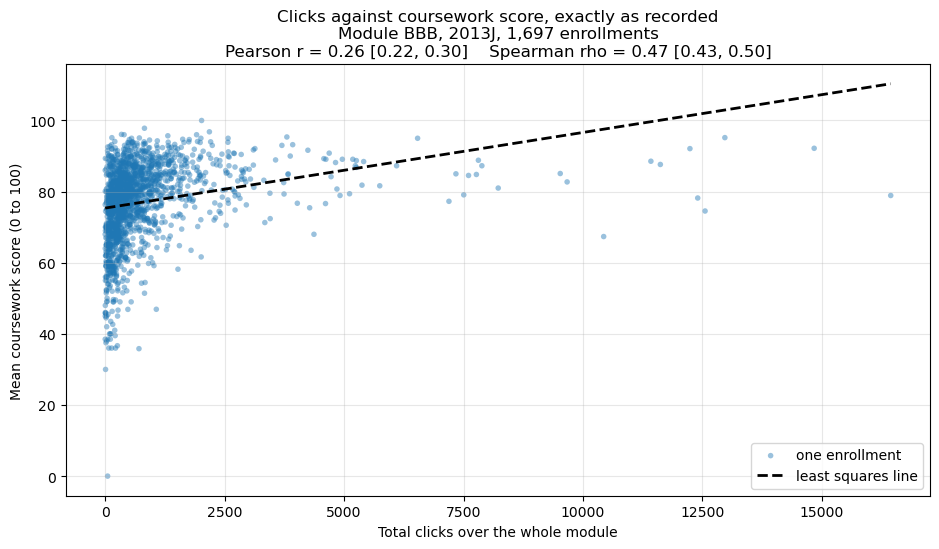

Pearson r (straight line, raw counts) = 0.258   95% interval [0.224, 0.296]
r squared                             = 0.067
   A straight line in raw clicks tracks about 7% of the variation in
   coursework scores, leaving about 93% doing something else.
Spearman rho (ranks)                  = 0.466   95% interval [0.425, 0.504]

Those two numbers disagree, and the disagreement is the finding. Pearson is small
because a straight line fits these points badly. Spearman is larger because the
ordering does hold: enrollments with more recorded clicks do tend to score higher.
The intervals are narrow, so neither number is a fluke of who happened to be in
this panel. Being precise is not the same as being right: both still describe
1,697 enrollments that had to survive an inner join to be here at all.
Neither number says why, and neither is a fact about any person in this file.


In [ ]:
r_raw = panel['total_clicks'].corr(panel['mean_score'])
rho = panel['total_clicks'].corr(panel['mean_score'], method='spearman')

# A 95% interval without a formula: resample the enrollments with replacement,
# recompute, repeat 2,000 times, keep the middle 95% of the answers.
def boot_ci(statistic, n, reps=2000, seed=8100):
    rng = np.random.default_rng(seed)
    vals = [statistic(rng.integers(0, n, n)) for _ in range(reps)]
    return np.percentile(vals, [2.5, 97.5])

n_panel = len(panel)
clicks_v = panel['total_clicks'].to_numpy(float)
score_v  = panel['mean_score'].to_numpy(float)
ranks    = lambda v: pd.Series(v).rank().to_numpy()

ci_raw = boot_ci(lambda s: np.corrcoef(clicks_v[s], score_v[s])[0, 1], n_panel)
ci_rho = boot_ci(lambda s: np.corrcoef(ranks(clicks_v[s]), ranks(score_v[s]))[0, 1], n_panel)

fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.scatter(panel['total_clicks'], panel['mean_score'],
           s=16, color='#1f77b4', alpha=0.45, edgecolor='none', label='one enrollment')

slope, intercept = np.polyfit(panel['total_clicks'], panel['mean_score'], 1)
xline = np.linspace(panel['total_clicks'].min(), panel['total_clicks'].max(), 100)
ax.plot(xline, slope * xline + intercept, color='#000000', linewidth=2,
        linestyle='--', label='least squares line')

ax.set_title('Clicks against coursework score, exactly as recorded\n'
             f'Module BBB, {PRESENTATION}, {len(panel):,} enrollments\n'
             f'Pearson r = {r_raw:.2f} [{ci_raw[0]:.2f}, {ci_raw[1]:.2f}]    '
             f'Spearman rho = {rho:.2f} [{ci_rho[0]:.2f}, {ci_rho[1]:.2f}]')
ax.set_xlabel('Total clicks over the whole module')
ax.set_ylabel('Mean coursework score (0 to 100)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'Pearson r (straight line, raw counts) = {r_raw:.3f}   '
      f'95% interval [{ci_raw[0]:.3f}, {ci_raw[1]:.3f}]')
print(f'r squared                             = {r_raw ** 2:.3f}')
print(f'   A straight line in raw clicks tracks about {100 * r_raw ** 2:.0f}% of the variation in')
print(f'   coursework scores, leaving about {100 - 100 * r_raw ** 2:.0f}% doing something else.')
print(f'Spearman rho (ranks)                  = {rho:.3f}   '
      f'95% interval [{ci_rho[0]:.3f}, {ci_rho[1]:.3f}]')
print()
print('Those two numbers disagree, and the disagreement is the finding. Pearson is small')
print('because a straight line fits these points badly. Spearman is larger because the')
print('ordering does hold: enrollments with more recorded clicks do tend to score higher.')
print('The intervals are narrow, so neither number is a fluke of who happened to be in')
print('this panel. Being precise is not the same as being right: both still describe')
print('1,697 enrollments that had to survive an inner join to be here at all.')
print('Neither number says why, and neither is a fact about any person in this file.')

**Let's look at the output.** Pearson `r` is 0.258 with an interval of [0.224, 0.296];
Spearman's rho on the same points is 0.466 with an interval of [0.425, 0.504]. The two disagree,
and the disagreement is the result to interpret.

What the pair supports, and what it does not:

| | |
|---|---|
| **What the data directly show** | Among the 1,697 enrollments in the panel, a straight line in raw clicks tracks about 7 percent of the variation in coursework scores, while the rank ordering of clicks and the rank ordering of scores agree considerably more closely. |
| **A plausible interpretation** | The relationship between recorded activity and coursework score is monotone but not straight, so a Pearson coefficient on raw counts understates how much the two orderings have in common. |
| **What this file cannot establish** | Anything about direction or cause, and anything about the 540 enrollments that had to survive an inner join to appear here at all. |

### Let's discuss

1. Most of the points are crushed against the left edge and a few run off to the right. What is
   that shape doing to the least squares line?
2. Pearson came out near 0.26 and Spearman near 0.47 on the same points. What are some plausible
   reasons two coefficients computed on identical data would differ that much, and what would you
   check to decide among them? Then say what the pair supports and what it does not.
3. Most of the variation in scores is doing something other than tracking click volume. It may be
   useful to name three plausible somethings, with at least two of them about the course or the
   measurement rather than about the students.
4. A vendor demo shows a university this chart and proposes an alert for students below the cohort
   median in activity. Using the claim ladder from Section 4, which rung is that pitch standing
   on, and which rung does it sound like it is standing on?

## 7. The same two variables, a different axis, a different Pearson r

Nobody in this analysis is about to change. No student will click more. No score will move. We are
going to put the identical data on the log x axis from Section 3, and the Pearson correlation
nearly doubles.

One thing to hold on to while it happens: **Spearman will not move at all.** A log is a monotone
transformation, so it leaves every enrollment's rank exactly where it was, and a rank correlation
cannot notice it. That is the cleanest available demonstration that what changes below is the fit
of an assumed shape rather than the strength of the relationship between these two columns.

First, the reason a log is arguable at all. The next cell splits the panel into ten equal groups
by click volume and shows what each step buys.

**Run the cell below.**

In [ ]:
panel['decile'] = pd.qcut(panel['total_clicks'], 10, labels=False) + 1
dec = (panel.groupby('decile')
            .agg(students=('id_student', 'size'),
                 median_clicks=('total_clicks', 'median'),
                 mean_score=('mean_score', 'mean'))
            .round(1))
display(dec)

d1, d5, d10 = dec.loc[1], dec.loc[5], dec.loc[10]
print(f'From decile 1 to decile 5 : +{d5.median_clicks - d1.median_clicks:,.0f} clicks '
      f'buys +{d5.mean_score - d1.mean_score:.1f} score points')
print(f'From decile 5 to decile 10: +{d10.median_clicks - d5.median_clicks:,.0f} clicks '
      f'buys +{d10.mean_score - d5.mean_score:.1f} score points')
print()
print(f'{(d10.median_clicks - d5.median_clicks) / (d5.median_clicks - d1.median_clicks):.1f} '
      'times the extra clicking, and roughly half the payoff.')
print('The relationship is not a straight line in clicks. It flattens.')
print('That is what a log scale is for.')

,students,median_clicks,mean_score
decile,,,
1,170,45.0,66.1
2,170,120.5,71.6
3,169,209.0,73.0
4,171,292.0,75.4
5,171,387.0,77.7
6,167,504.0,79.4
7,170,665.5,80.1
8,169,896.0,80.5
9,170,1299.0,82.8


From decile 1 to decile 5 : +342 clicks buys +11.6 score points
From decile 5 to decile 10: +2,198 clicks buys +6.5 score points

6.4 times the extra clicking, and roughly half the payoff.
The relationship is not a straight line in clicks. It flattens.
That is what a log scale is for.


**Let's look at the output.** From decile 1 to decile 5, an extra 342 clicks at the median goes
with 11.6 more score points. From decile 5 to decile 10, an extra 2,198 clicks goes with 6.5 more.
That is about 6.4 times the additional clicking for roughly half the movement in score. The
relationship is not a straight line in clicks; it flattens, and flattening is the situation a log
scale is built for.

**Run the cell below** for the two scatterplots side by side. The only difference between them is
one function call, `np.log10` applied to the x value. No score is touched, no click count is
touched, and no student is added or removed. The two Pearson numbers are in the titles, and the
Spearman line underneath does not move.

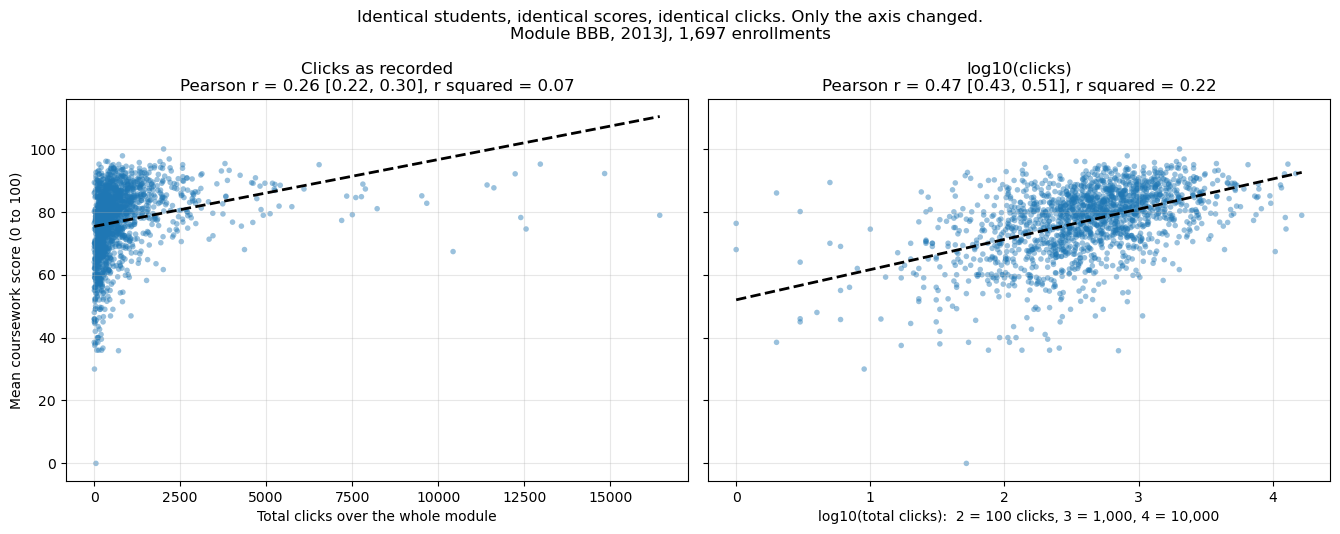

Pearson r, raw click count : 0.258   [0.224, 0.296]   (r squared 0.067)
Pearson r, log10(clicks)   : 0.473   [0.429, 0.511]   (r squared 0.223)
Difference                 : 0.214   [0.173, 0.251]
   That interval is worth reading closely. It says the better fit is not a fluke of these
   particular enrollments. It does NOT say the relationship is stronger, because
   the two correlations describe the same people and the same behavior.

Spearman rho, raw click count : 0.466   [0.425, 0.504]
Spearman rho, log10(clicks)   : 0.466      <- identical, to every decimal
A log leaves every enrollment in the same rank order, so a rank correlation cannot
see it at all. Nothing about the relationship got stronger. A different assumed
shape fit better.

Reported one way: "a straight line in raw clicks tracks 7% of the score variation."
Reported the other: "a straight line in log clicks tracks 22%."
Both are true about the same 1,697 enrollments, and neither says how much
clicking causes.


In [ ]:
panel['log_clicks'] = np.log10(panel['total_clicks'])
r_log = panel['log_clicks'].corr(panel['mean_score'])
rho_log = panel['log_clicks'].corr(panel['mean_score'], method='spearman')

logc_v = panel['log_clicks'].to_numpy(float)
ci_log = boot_ci(lambda s: np.corrcoef(logc_v[s], score_v[s])[0, 1], n_panel)
# The same resampled enrollments feed both correlations, so this is an interval on
# the difference between two numbers computed on one set of people, not on two samples.
ci_diff = boot_ci(lambda s: (np.corrcoef(logc_v[s], score_v[s])[0, 1]
                             - np.corrcoef(clicks_v[s], score_v[s])[0, 1]), n_panel)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.4), sharey=True)

for ax, xcol, title, xlabel in [
        (ax1, 'total_clicks',
         f'Clicks as recorded\nPearson r = {r_raw:.2f} [{ci_raw[0]:.2f}, {ci_raw[1]:.2f}], '
         f'r squared = {r_raw ** 2:.2f}',
         'Total clicks over the whole module'),
        (ax2, 'log_clicks',
         f'log10(clicks)\nPearson r = {r_log:.2f} [{ci_log[0]:.2f}, {ci_log[1]:.2f}], '
         f'r squared = {r_log ** 2:.2f}',
         'log10(total clicks):  2 = 100 clicks, 3 = 1,000, 4 = 10,000')]:
    ax.scatter(panel[xcol], panel['mean_score'], s=16, color='#1f77b4',
               alpha=0.45, edgecolor='none')
    s, i = np.polyfit(panel[xcol], panel['mean_score'], 1)
    xs = np.linspace(panel[xcol].min(), panel[xcol].max(), 100)
    ax.plot(xs, s * xs + i, color='#000000', linewidth=2, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel(xlabel)

ax1.set_ylabel('Mean coursework score (0 to 100)')
fig.suptitle('Identical students, identical scores, identical clicks. Only the axis changed.\n'
             f'Module BBB, {PRESENTATION}, {len(panel):,} enrollments', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Pearson r, raw click count : {r_raw:.3f}   [{ci_raw[0]:.3f}, {ci_raw[1]:.3f}]'
      f'   (r squared {r_raw ** 2:.3f})')
print(f'Pearson r, log10(clicks)   : {r_log:.3f}   [{ci_log[0]:.3f}, {ci_log[1]:.3f}]'
      f'   (r squared {r_log ** 2:.3f})')
print(f'Difference                 : {r_log - r_raw:.3f}   [{ci_diff[0]:.3f}, {ci_diff[1]:.3f}]')
print('   That interval is worth reading closely. It says the better fit is not a fluke of these')
print('   particular enrollments. It does NOT say the relationship is stronger, because')
print('   the two correlations describe the same people and the same behavior.')
print()
print(f'Spearman rho, raw click count : {rho:.3f}   [{ci_rho[0]:.3f}, {ci_rho[1]:.3f}]')
print(f'Spearman rho, log10(clicks)   : {rho_log:.3f}      <- identical, to every decimal')
print('A log leaves every enrollment in the same rank order, so a rank correlation cannot')
print('see it at all. Nothing about the relationship got stronger. A different assumed')
print('shape fit better.')
print()
print(f'Reported one way: "a straight line in raw clicks tracks {100 * r_raw ** 2:.0f}% of the score variation."')
print(f'Reported the other: "a straight line in log clicks tracks {100 * r_log ** 2:.0f}%."')
print(f'Both are true about the same {len(panel):,} enrollments, and neither says how much')
print('clicking causes.')

**Let's discuss.** The log version is not a trick. It is defensible, and here is the defense:
click counts are heavy tailed, and the decile table shows the movement in score flattening, so a
model that treats a step of a few hundred clicks at the bottom of the distribution as equivalent
to the same step at the top is modeling something few people believe. Logging says *proportional*
change is what matters. That is a claim about how learning works, and it can be argued for.

The raw version is also defensible: clicks are what the system counted, and transforming them adds
the analyst's own reasoning to what the reader is shown.

What is harder to defend is choosing between them after seeing which one gives the bigger number.

It is worth being precise about what the log bought. Spearman is 0.466 before the transformation
and 0.466 after it. The association between these two columns did not change and could not have
changed. What the transformation did was replace a badly fitting straight line with a better
fitting one. The interval on the difference, 0.214 [0.173, 0.251], says the better fit is
repeatable, which is a narrower statement than it looks: a fit improvement you could reproduce a
thousand times is still a fit improvement rather than a discovery about students. A paper that
reports the jump from 7 percent to 22 percent without mentioning that the rank correlation did not
move is not stating a falsehood, and it is letting a reader believe something the data do not
support.

*Connecting to the readings.* Reich (2022) writes about studying learning at scale through
whatever traces a platform happens to keep. This section suggests one clause to add: and through
whatever transformations the analyst happens to apply. Both the trace and the transformation are
choices somebody made, and neither of them is visible in a reported coefficient.

1. You are writing the results paragraph. Which numbers do you report, and what has to sit
   alongside them so that a reader could disagree with you?
2. A colleague reports the log version with no mention of the transformation. How would you
   characterize that, and does your answer change if they are selling a product?
3. Where does the transformation sit on the claim ladder? It is not a feature and it is not a
   construct. What would you call it?
4. An interval tells you how much a number would wobble with a different sample of the same kind
   of people. What is one thing that could be wrong with a correlation that a narrow interval
   would not warn you about? Section 5b printed one of them.

## 8. The students the line gets wrong

A regression line is an average, and an average describes nobody in particular. Two views make the
misses visible.

First, a summary table: the panel split into three equal groups by click volume, with the
**spread** of scores inside each group beside the average.

**Run the cell below.**

In [ ]:
panel['tercile'] = pd.qcut(panel['total_clicks'], 3,
                           labels=['low third', 'middle third', 'high third'])

tercile_table = (
    panel.groupby('tercile', observed=True)
         .agg(students=('id_student', 'count'),
              median_clicks=('total_clicks', 'median'),
              mean_score=('mean_score', 'mean'),
              sd_of_score=('mean_score', 'std'),
              lowest_score=('mean_score', 'min'),
              highest_score=('mean_score', 'max'))
         .round(1)
)
display(tercile_table)

high_median = panel.loc[panel['tercile'] == 'high third', 'mean_score'].median()
low_group = panel[panel['tercile'] == 'low third']
n_beat = int((low_group['mean_score'] > high_median).sum())
print(f'Median score of the HIGH click third: {high_median:.1f}')
print(f'Low click students who beat that median: {n_beat} of {len(low_group)} '
      f'({100 * n_beat / len(low_group):.1f}%)')
print(f'Distance between the low and high group means: '
      f'{tercile_table.loc["high third", "mean_score"] - tercile_table.loc["low third", "mean_score"]:.1f} points')
print(f'Spread inside the low group alone (sd): '
      f'{tercile_table.loc["low third", "sd_of_score"]:.1f} points')

,students,median_clicks,mean_score,sd_of_score,lowest_score,highest_score
tercile,,,,,,
low third,566,137.5,70.5,12.4,0.0,95.2
middle third,565,439.0,78.7,8.4,46.9,96.1
high third,566,1176.0,82.1,8.2,35.8,100.0


Median score of the HIGH click third: 83.4
Low click students who beat that median: 72 of 566 (12.7%)
Distance between the low and high group means: 11.6 points
Spread inside the low group alone (sd): 12.4 points


**Let's look at the output.** The group means climb from the low third to the high third, so the
trend is present. The column to read next to them is `sd_of_score`, along with `lowest_score`
against `highest_score` **within** any one row: the range inside a single activity group is far
wider than the distance between the groups. The low third means 70.5 and the high third 82.1, a
gap of 11.6 points, while the standard deviation inside the low third alone is 12.4. That is what
a modest `r` looks like when one line is used to describe seventeen hundred people.

The next cell finds the enrollments in the **low activity, high score** corner: bottom third of
clicks, top quarter of scores.

**Run the cell below.**

Click cutoff (33rd percentile) : 274 clicks
Score cutoff (75th percentile) : 84.8 points
Enrollments in the low click, high score corner: 60 of 1,697
Compared to what? If clicks and scores were unrelated, a third of the panel crossed
with a quarter of it would put about 141 enrollments in that box. There are 60.
The corner is smaller than chance, which is the same association Section 6 measured,
seen from the other end. It is also not empty, which is the point of the next chart.

Their median click count: 145, against 439 for the panel as a whole.

How those corner enrollments actually ended:
final_result
Distinction     9
Pass           21
Fail           17
Withdrawn      13
Withdrawn: 13 of 60 (21.7%), 95% interval [11.7%, 33.3%],
against 12.0% of the panel. With 60 enrollments that interval
reaches down to the panel rate, so this corner is not a demonstrably different
kind of ending. Sixty is enough to show the corner exists. Not enough to
describe the people in it, and the next cha

,id_student,total_clicks,active_days,n_submissions,mean_score,final_result
0,556427,141,20,6,95.166667,Withdrawn
1,398891,203,29,11,94.090909,Pass
2,2620279,136,13,5,93.200000,Withdrawn
3,517553,103,6,5,92.800000,Withdrawn
4,305935,53,5,11,92.545455,Fail
5,520006,213,20,11,92.272727,Distinction
6,574065,145,15,11,92.000000,Distinction
7,440765,137,23,3,92.000000,Fail
8,509258,259,7,4,91.500000,Fail
9,440593,51,6,8,91.500000,Pass


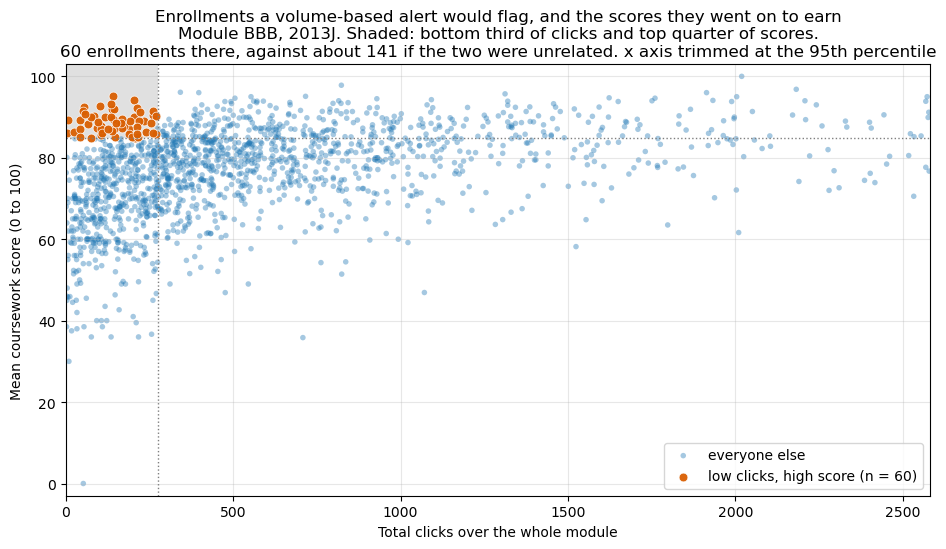

In [ ]:
click_cut = panel['total_clicks'].quantile(1 / 3)
score_cut = panel['mean_score'].quantile(0.75)

corner = panel[(panel['total_clicks'] <= click_cut) & (panel['mean_score'] >= score_cut)]
expected = len(panel) * (1 / 3) * 0.25

print(f'Click cutoff (33rd percentile) : {click_cut:,.0f} clicks')
print(f'Score cutoff (75th percentile) : {score_cut:.1f} points')
print(f'Enrollments in the low click, high score corner: {len(corner)} of {len(panel):,}')
print(f'Compared to what? If clicks and scores were unrelated, a third of the panel crossed')
print(f'with a quarter of it would put about {expected:.0f} enrollments in that box. There are '
      f'{len(corner)}.')
print('The corner is smaller than chance, which is the same association Section 6 measured,')
print('seen from the other end. It is also not empty, which is the point of the next chart.')
print()
print(f'Their median click count: {corner["total_clicks"].median():,.0f}, '
      f'against {panel["total_clicks"].median():,.0f} for the panel as a whole.')
print()
print('How those corner enrollments actually ended:')
print(corner['final_result'].value_counts()
      .reindex(['Distinction', 'Pass', 'Fail', 'Withdrawn']).to_string())

wd_corner = (corner['final_result'] == 'Withdrawn').to_numpy()
ci_wd = boot_ci(lambda s: wd_corner[s].mean(), len(corner))
print(f'Withdrawn: {wd_corner.sum()} of {len(corner)} ({100 * wd_corner.mean():.1f}%), '
      f'95% interval [{100 * ci_wd[0]:.1f}%, {100 * ci_wd[1]:.1f}%],')
print(f'against {100 * (panel["final_result"] == "Withdrawn").mean():.1f}% of the panel. '
      f'With {len(corner)} enrollments that interval')
print('reaches down to the panel rate, so this corner is not a demonstrably different')
print('kind of ending. Sixty is enough to show the corner exists. Not enough to')
print('describe the people in it, and the next chart is a map, not a claim.')
print()
print('The ten highest scorers in that corner:')
display(corner[['id_student', 'total_clicks', 'active_days', 'n_submissions',
                'mean_score', 'final_result']]
        .sort_values('mean_score', ascending=False).head(10).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9.5, 5.6))
x_lo, x_hi = 0, panel['total_clicks'].quantile(0.95)
y_lo, y_hi = panel['mean_score'].min() - 3, 103
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)

ax.add_patch(plt.Rectangle((x_lo, score_cut), click_cut - x_lo, y_hi - score_cut,
                           facecolor='#bbbbbb', alpha=0.45, zorder=0))
ax.axhline(score_cut, color='#7f7f7f', linewidth=1, linestyle=':')
ax.axvline(click_cut, color='#7f7f7f', linewidth=1, linestyle=':')

others = panel.drop(corner.index)
ax.scatter(others['total_clicks'], others['mean_score'], s=16, color='#1f77b4',
           alpha=0.40, edgecolor='none', label='everyone else')
ax.scatter(corner['total_clicks'], corner['mean_score'], s=40, color='#d95f02',
           alpha=0.95, edgecolor='white', linewidth=0.5,
           label=f'low clicks, high score (n = {len(corner)})')

ax.set_title('Enrollments a volume-based alert would flag, and the scores they went on to earn\n'
             f'Module BBB, {PRESENTATION}. Shaded: bottom third of clicks and top quarter of scores.\n'
             f'{len(corner)} enrollments there, against about {expected:.0f} if the two were unrelated. '
             'x axis trimmed at the 95th percentile')
ax.set_xlabel('Total clicks over the whole module')
ax.set_ylabel('Mean coursework score (0 to 100)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Let's look at the output.** Sixty enrollments sit in the shaded corner, several of them near
the top of the cohort, on a median of 145 clicks against the panel's 439. Sixty is fewer than the
roughly 141 you would expect there if clicks and scores had nothing to do with each other, and it
is a good deal more than none.

| | |
|---|---|
| **What the data directly show** | 60 of the 1,697 enrollments are in the bottom third of clicks and the top quarter of coursework scores. Nine ended in `Distinction`, 21 in `Pass`, 17 in `Fail`, and 13 in `Withdrawn`, one of the 13 with a coursework average above 95. |
| **A plausible interpretation** | For these enrollments, recorded click volume is not tracking whatever produced the coursework scores. |
| **What this file cannot establish** | Whether the corner's 21.7 percent withdrawal share differs from the panel's 12.0 percent, since on 60 enrollments the interval runs from 11.7 to 33.3 percent and reaches down to the panel's own rate. |

### Let's discuss

1. Three different stories would each produce a point in that corner: one flattering to the
   student, one worrying, and one about the **system** rather than the student. This is a
   distance-learning module, so it may be worth asking where else the studying could have
   happened.
2. An alert built on click volume would flag the person with the 95 average. What does it know
   about them, and what does it not?
3. A retention model that treats low recorded activity as a warning sign would flag all sixty.
   What is the cost of that error, and who pays it? Week 3 builds that model and audits it,
   starting with the question of what it should be called.
4. Turning the frame around: the busiest third average only a few points above the middle third.
   If more recorded activity goes with so little movement in score, what might that say about the
   course materials, the assessment, and the platform, before it says anything about the students?
   What data would help distinguish among those?
5. Baker and Siemens (2014) separate discovering structure in data from acting on it. Which of
   the two is happening when these sixty enrollments are circled, and which one would need
   permission?

## Your turn 1: the cleaning decisions

Every number above rests on decisions made in Section 2. Here they are yours.

Each of the three switches below is a defensible position that an analyst has taken in a published
paper. Change them, re-run, and two things move: **how many people are left**, and **what the
headline number becomes**.

The cell runs as written and reproduces the panel you already have, so it may be useful to run it
once before changing anything.

- `INCLUDE_PRE_START_CLICKS`: keep the clicks recorded before day 0, or set them aside because the
  exposure window is unequal?
- `MIN_SUBMISSIONS`: how many scored submissions must a student have before they count as having a
  coursework score? One is generous; three requires a record of submitted work.
- `KEEP_WITHDRAWN`: keep enrollments that ended in withdrawal, or restrict to students who stayed?

Nobody's behavior changes. Only who counts changes.

**Run the cell below**, then change a value and run it again.

In [ ]:
# EDIT THESE THREE VALUES. The cell runs as written.
INCLUDE_PRE_START_CLICKS = True    # True or False
MIN_SUBMISSIONS          = 1       # 1, 2, 3, ...
KEEP_WITHDRAWN           = True    # True or False

# --- nothing below needs editing ---
def build_panel(presentation='2013J', include_pre_start=True,
                min_submissions=1, keep_withdrawn=True):
    """Rebuild the whole panel under one set of cleaning decisions."""
    roster_p = student_info[student_info['code_presentation'] == presentation]
    if not keep_withdrawn:
        roster_p = roster_p[roster_p['final_result'] != 'Withdrawn']

    log = student_vle[student_vle['code_presentation'] == presentation]
    if not include_pre_start:
        log = log[log['date'] >= 0]
    act = log.groupby('id_student').agg(total_clicks=('sum_click', 'sum')).reset_index()

    sc = submissions[submissions['code_presentation'] == presentation].dropna(subset=['score'])
    ach = (sc.groupby('id_student')
             .agg(mean_score=('score', 'mean'), n_submissions=('score', 'size'))
             .reset_index())
    ach = ach[ach['n_submissions'] >= min_submissions]

    return (roster_p[['id_student', 'final_result']]
            .merge(act, on='id_student', how='inner')
            .merge(ach, on='id_student', how='inner'))

p = build_panel(PRESENTATION, INCLUDE_PRE_START_CLICKS, MIN_SUBMISSIONS, KEEP_WITHDRAWN)
rr = p['total_clicks'].corr(p['mean_score'])
rl = np.log10(p['total_clicks']).corr(p['mean_score'])
rs = p['total_clicks'].corr(p['mean_score'], method='spearman')

print(f'pre-start clicks kept : {INCLUDE_PRE_START_CLICKS}')
print(f'minimum submissions   : {MIN_SUBMISSIONS}')
print(f'withdrawn kept        : {KEEP_WITHDRAWN}')
print('-' * 60)
print(f'enrollments analyzed  : {len(p):,}   '
      f'(baseline {len(panel):,}; started from {len(enroll):,} enrolled)')
print(f'median clicks         : {p["total_clicks"].median():,.0f}')
print(f'mean coursework score : {p["mean_score"].mean():.1f}')
print(f'share withdrawn       : {100 * (p["final_result"] == "Withdrawn").mean():.1f}%')
print(f'Pearson r, raw clicks : {rr:.3f}   (baseline {r_raw:.3f})')
print(f'Pearson r, log clicks : {rl:.3f}   (baseline {r_log:.3f})')
print(f'Spearman rho          : {rs:.3f}   (baseline {rho:.3f})')
print('-' * 60)
print(f'Enrolled people your settings leave out: {len(enroll) - len(p):,}')

pre-start clicks kept : True
minimum submissions   : 1
withdrawn kept        : True
------------------------------------------------------------
enrollments analyzed  : 1,697   (baseline 1,697; started from 2,237 enrolled)
median clicks         : 439
mean coursework score : 77.1
share withdrawn       : 12.0%
Pearson r, raw clicks : 0.258   (baseline 0.258)
Pearson r, log clicks : 0.473   (baseline 0.473)
Spearman rho          : 0.466   (baseline 0.466)
------------------------------------------------------------
Enrolled people your settings leave out: 540


**Let's discuss.** No student's behavior changed. Who counts changed, and both the sample and
the headline number moved with it.

You might write one sentence naming the setting you would defend in a methods section, and one
sentence naming what a reader would need to be told about the people it removed.

One thing worth noticing: the pre-start switch barely moves anything, while `MIN_SUBMISSIONS`
moves a lot. Decisions are not equally consequential, and there is no way to tell which is which
without checking. That check has a name in the literature: a **sensitivity analysis**.

## 9. When does the work happen?

So far we have ignored time. Every count in this notebook has treated a click on day 3 and a click
on day 200 as the same thing, and the educational interest is usually in the timing.

This module ran for months and had assignments due on known days. The next cell counts clicks per
day and marks every due date, and beside it counts how many distinct students were still active in
each week of the module.

**Run the cell below.**

Tutor-marked assignment due days   : [19, 47, 96, 131, 166, 208]
Computer-marked assignment due days: [54, 96, 131, 166, 208]
The exam has no due day recorded and no submissions in the file.

Days of activity before the module opens: 11, carrying 63,524 clicks (4.6% of the total).
Busiest day: day 2, 19,872 clicks from 698 students.
Mean clicks per day from day 0 onward: 4,889
Mean clicks per day in the 7 days up to the first assignment (day 19): 10,662

The log ends on day 268, so module week 38 holds only 3 days.
The weekly panel below stops at week 37, the last complete week, so every point counts 7 days.
Distinct students active in module week 0  : 1,372
Distinct students active in module week 37 : 381

Weeks the line went UP rather than down: 14 of 37
The five biggest rebounds, by week: [12, 13, 29, 23, 34]
Weeks a tutor-marked assignment was due: [2, 6, 13, 18, 23, 29]
Attrition here is a sawtooth, not a slide.


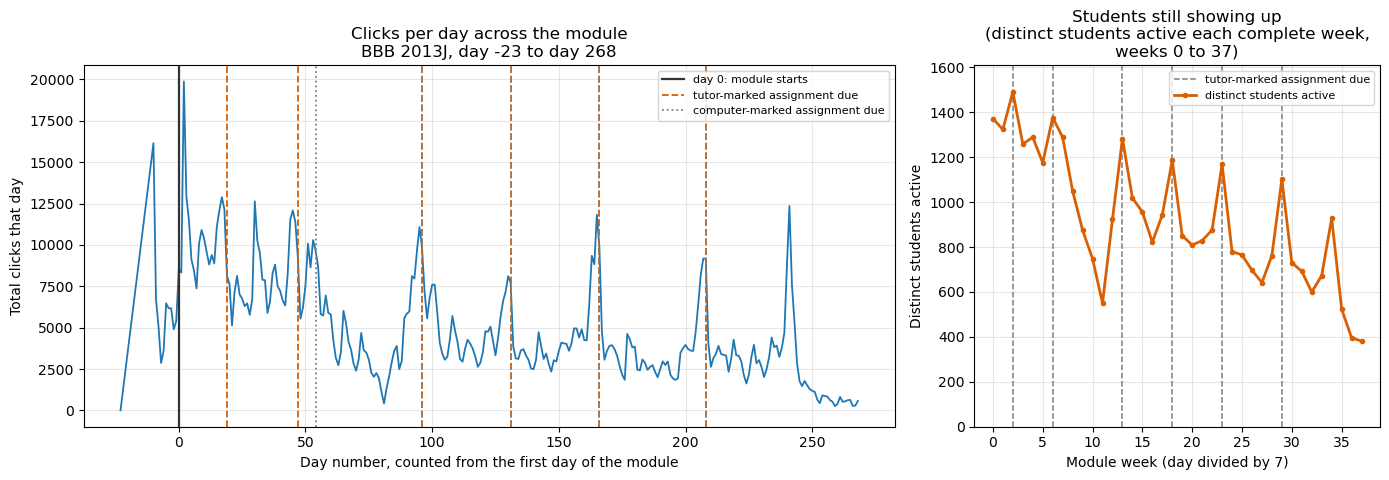

In [ ]:
daily = (vle_log.groupby('date')
                .agg(clicks=('sum_click', 'sum'), students=('id_student', 'nunique'))
                .reset_index())

due = assessments[(assessments['code_presentation'] == PRESENTATION)
                  & assessments['date'].notna()]
tma_days = sorted(due[due['assessment_type'] == 'TMA']['date'].tolist())
cma_days = sorted(due[due['assessment_type'] == 'CMA']['date'].tolist())
print('Tutor-marked assignment due days   :', [int(v) for v in tma_days])
print('Computer-marked assignment due days:', [int(v) for v in cma_days])
print('The exam has no due day recorded and no submissions in the file.')
print()

pre_days = daily[daily['date'] < 0]
print(f'Days of activity before the module opens: {len(pre_days)}, '
      f'carrying {pre_days["clicks"].sum():,} clicks '
      f'({100 * pre_days["clicks"].sum() / daily["clicks"].sum():.1f}% of the total).')
peak = daily.loc[daily['clicks'].idxmax()]
print(f'Busiest day: day {int(peak["date"])}, {int(peak["clicks"]):,} clicks '
      f'from {int(peak["students"]):,} students.')
print(f'Mean clicks per day from day 0 onward: '
      f'{daily.loc[daily["date"] >= 0, "clicks"].mean():,.0f}')
first_due = tma_days[0]
print(f'Mean clicks per day in the 7 days up to the first assignment (day {int(first_due)}): '
      f'{daily[(daily["date"] >= first_due - 6) & (daily["date"] <= first_due)]["clicks"].mean():,.0f}')
print()

# A weekly count is only comparable across weeks that are the same length. The log ends
# on day 268, so the last bucket would hold 3 days against everyone else's 7. Drop it,
# and say so, rather than drawing a cliff the calendar put there.
last_day   = int(vle_log['date'].max())
full_weeks = (last_day + 1) // 7
print(f'The log ends on day {last_day}, so module week {full_weeks} holds only '
      f'{last_day - full_weeks * 7 + 1} days.')
print(f'The weekly panel below stops at week {full_weeks - 1}, the last complete week, '
      'so every point counts 7 days.')
weekly = (vle_log[(vle_log['date'] >= 0) & (vle_log['date'] < full_weeks * 7)]
          .assign(week=lambda t: t['date'] // 7)
          .groupby('week')['id_student'].nunique())
print(f'Distinct students active in module week {weekly.index[0]}  : {weekly.iloc[0]:,}')
print(f'Distinct students active in module week {weekly.index[-1]} : {weekly.iloc[-1]:,}')
print()

# The weekly line trends down, but it does not fall smoothly. Where does it bounce?
tma_weeks = sorted({int(v) // 7 for v in tma_days})
change = weekly.diff()
rises = change[change > 0].sort_values(ascending=False)
print(f'Weeks the line went UP rather than down: {int((change > 0).sum())} of '
      f'{int(change.notna().sum())}')
print(f'The five biggest rebounds, by week: {[int(w) for w in rises.head(5).index]}')
print(f'Weeks a tutor-marked assignment was due: {tma_weeks}')
print('Attrition here is a sawtooth, not a slide.')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.9),
                               gridspec_kw={'width_ratios': [2.0, 1.0]})

ax1.plot(daily['date'], daily['clicks'], color='#1f77b4', linewidth=1.3)
ax1.axvline(0, color='#333333', linewidth=1.6, label='day 0: module starts')
for i, dday in enumerate(tma_days):
    ax1.axvline(dday, color='#d95f02', linestyle='--', linewidth=1.3,
                label='tutor-marked assignment due' if i == 0 else None)
for i, dday in enumerate(cma_days):
    ax1.axvline(dday, color='#7f7f7f', linestyle=':', linewidth=1.3,
                label='computer-marked assignment due' if i == 0 else None)
ax1.set_title(f'Clicks per day across the module\nBBB {PRESENTATION}, '
              f'day {int(daily["date"].min())} to day {int(daily["date"].max())}')
ax1.set_xlabel('Day number, counted from the first day of the module')
ax1.set_ylabel('Total clicks that day')
ax1.legend(fontsize=8, loc='upper right')

for i, w in enumerate(tma_weeks):
    ax2.axvline(w, color='#7f7f7f', linestyle='--', linewidth=1.1,
                label='tutor-marked assignment due' if i == 0 else None)
ax2.plot(weekly.index, weekly.values, color='#d95f02', linewidth=2, marker='o', markersize=3,
         label='distinct students active')
ax2.set_title('Students still showing up\n(distinct students active each complete week,\n'
              f'weeks 0 to {full_weeks - 1})')
ax2.set_xlabel('Module week (day divided by 7)')
ax2.set_ylabel('Distinct students active')
ax2.set_ylim(0, weekly.max() * 1.08)
ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

### Let's discuss

1. The left panel has a regular cycle. How would you describe it in one sentence, and what in the
   course design might produce it?
2. Most orange lines are followed by a drop. What are some plausible readings of that, and what
   might this panel look like in a module with no fixed due dates?
3. The right panel is attrition drawn as a line, and it does not fall smoothly. It starts at 1,372
   students in week 0, ends at 381 in week 37, and goes back up in 14 of its 37 steps. Comparing
   the printed list of the five biggest rebounds against the printed list of assignment weeks,
   three of the five land on a tutor-marked deadline week and a fourth is the week before one.
   What are some plausible explanations for that sawtooth, and what additional information would
   help distinguish among them? Could a dashboard that counts weekly active users tell the
   difference?
4. The panel stops at week 37 on purpose. The log runs three days into week 38, and a three-day
   week counts fewer distinct people than a seven-day week whatever anybody did. Plotting it would
   draw a final drop that is entirely an artifact of where the file ends. Where else in this
   notebook does a count depend on the length of the window it was counted over, and how would you
   tell an artifact from a finding?
5. Clicks keep going after the last assignment due day. What might those people be doing, and
   which column in this dataset would you check first?
6. Reich (2022) writes about what happens when learning is studied at scale through the traces
   platforms happen to keep. Is this rhythm mostly a trace of the students, or of the calendar the
   institution set for them, and how would you tell?

## 10. Reflection

These are for the closing discussion. A few sentences each is plenty, and there are no wrong
answers here.

**1. Baker and Siemens (2014), educational data mining and learning analytics.**
Today's work did something both traditions do: reduce behavior to features, then look for
structure. It may be useful to sketch the next step twice.
- The educational data mining version: what would you automate, model, or predict from this panel?
- The learning analytics version: whose decision would you inform, what would you show them, and
  how would a human's judgment stay in the loop?

Which of the two is your course project closer to right now, and is that on purpose?

**2. Nathan and Sawyer (2014), foundations of the learning sciences.**
Their account describes learning as deep conceptual understanding built through activity in
context rather than as accumulated exposure. Looking back at Section 6:
- Which rung of the claim ladder can `total_clicks` reach, on that account of learning?
- This was a distance-learning module. What is one thing a learning sciences researcher would want
  to observe about it that leaves no trace in any file we opened today?
- If you could add exactly one new column to this dataset to get closer to their idea of learning,
  what would it be, and how would you collect it without surveilling anybody?

**3. Reich (2022), learning analytics and learning at scale.**
Section 7 gave two true sentences about the same people, one reporting a small share of score
variation tracked by a straight line in raw clicks and one reporting roughly three times as much,
differing only in the axis, while the rank correlation underneath both did not move.
- What does that do to your reading of any single reported effect size in the literature?
- If a paper reports one correlation and does not say what shape it assumed, what would you want
  to ask for before believing it?
- Reich argues that scale changes what can be known. Does it also change what can be *claimed*,
  and who checks?

**4. The people who are not in the panel.**
Every enrollment the inner join set aside had failed or withdrawn. Not one had passed.
- What sentence would you put in a limitations section? Then what sentence would you put in an
  abstract, and are they the same sentence?
- Whose responsibility is it that the students most likely to need help are the students least
  visible in the data? Is that a technical problem, a design problem, or a political one?

**5. One question this data cannot answer.**
Please write it down and bring it to the discussion. Some of the best course projects in this
seminar have started as this kind of sentence.

## 11. Wrap up

**Nothing from this notebook is collected.** It is in-class work, and coding skill is not what is
assessed anywhere in this course. Mini Project 1 arrives in Week 4, and that is when the formal
submission routine starts.

Before you close the tab:

- [ ] The notebook ran top to bottom.
- [ ] I can say where this data came from, who collected it, and under what license, without
      scrolling up.
- [ ] I edited a **Your turn** cell and saw a number move.
- [ ] I wrote something in the claim ladder text cell in Section 4.
- [ ] I can say, in one sentence, what our analysis panel is a sample **of**.
- [ ] I have one sentence ready for discussion: a question this data cannot answer.
- [ ] I saved my copy: **File > Save a copy in Drive**. Colab sessions do not persist, and the
      download runs again from scratch next time.

**On AI use.** No AI documentation is required for this notebook, because nothing from it is
collected. Starting with Mini Project 1 in Week 4, every mini project submission on Canvas
includes your completed notebook, an **AI interaction log in an attached Word file**, and a short
reflection **in the Canvas text box**, per the course AI policy. Undisclosed AI use is an Honor
Code matter. If you used a chatbot to make sense of `groupby` today, that is a fine use, and
starting the habit now tends to be easier than starting it under a deadline.

**On citing the data.** If any part of your course project uses this dataset, the CC BY 4.0
license requires attribution. Cite Kuzilek, Hlosta, and Zdrahal (2017), *Scientific Data, 4*,
170171, and say which module and presentation you used. "OULAD" on its own is not a citation.

**Coming in Week 3.** We take the activity features built today and train a model that predicts
one thing: whether an enrollment ends in Fail or Withdrawn. Then we audit who it flags and who it
misses, by subgroup. The first decision we make together is what to call the thing being
predicted, because the field's usual name for it describes a person rather than an outcome. The
sixty enrollments in the corner come back, and so does `imd_band`, with its inconsistent label and
its blanks.

## Going further (optional)

Everything below is optional and not needed for today's session. Please feel free to stop here.

Three pieces sit here: a closer look at what the correlation in Section 7 is made of, the same
analysis run on the other year, and a cell that lets you change what counts as a click. Each one
runs on its own, and the appendix at the end gives the expected numbers for all three **Your
turn** cells.

### What is that 0.47 made of?

Two things are inside the headline number from Section 7, and neither is about how hard anybody
worked.

**How far into the module the enrollment got.** Somebody who left in November sat two assessments;
somebody who stayed to the end sat eleven. More assessments means more weeks of the course, and
more weeks of the course means more clicks *and* a coursework mean assembled from a different set
of assessments. Part of what `log10(clicks)` and `mean_score` share is therefore length of stay,
which is a fact about a calendar and a fee-refund window before it is a fact about a person. The
cell below holds the number of scored submissions fixed and reports what is left.

**Which assessments the mean is a mean of.** Section 5 noted that the unweighted mean was wrong in
a statable way. Here is the statement. Computer-marked and tutor-marked assessments do not score
alike, and the module's own weights say one of the two barely counts toward the coursework mark.
An unweighted mean lets the mix a student happened to sit move their score, and then lets that
movement into the correlation.

Neither of these makes the earlier number wrong. They make it *partly about something else*.

**Run the cell below.**

In [ ]:
# Ingredient one: number of scored submissions, roughly how far the enrollment got.
r_xy = panel['log_clicks'].corr(panel['mean_score'])
r_xz = panel['log_clicks'].corr(panel['n_submissions'])
r_yz = panel['mean_score'].corr(panel['n_submissions'])
partial = (r_xy - r_xz * r_yz) / np.sqrt((1 - r_xz ** 2) * (1 - r_yz ** 2))

print('Pairwise, in this panel:')
print(f'  log10(clicks) with coursework score      : {r_xy:.3f}')
print(f'  log10(clicks) with number of submissions : {r_xz:.3f}')
print(f'  score         with number of submissions : {r_yz:.3f}')
print(f'Holding the number of submissions fixed:     {partial:.3f}')
print(f'The headline {r_xy:.2f} falls to {partial:.2f}. Roughly a third of it was shared with how')
print('many assessments the enrollment lived long enough to sit.')
print()

# Ingredient two: the mix of assessment types inside an unweighted mean.
print('Scores by assessment type in this presentation:')
display(subs.groupby('assessment_type')['score'].agg(submissions='size', mean_score='mean').round(1))

parts = subs.assign(weighted=subs['score'] * subs['weight'])
weighted = (parts.groupby('id_student')
                 .agg(num=('weighted', 'sum'), den=('weight', 'sum'))
                 .assign(weighted_score=lambda t: t['num'] / t['den'])
                 .reset_index()[['id_student', 'weighted_score']])
w = panel.merge(weighted, on='id_student')
r_w   = np.log10(w['total_clicks']).corr(w['weighted_score'])
rho_w = w['total_clicks'].corr(w['weighted_score'], method='spearman')

print(f'Achievement as an unweighted mean : Pearson on log clicks {r_log:.3f}, Spearman {rho:.3f}')
print(f'Achievement using module weights  : Pearson on log clicks {r_w:.3f}, Spearman {rho_w:.3f}')
print('Same students, same clicks, same scores. A different definition of achievement,')
print('and this time the rank correlation does move, because the ordering itself changed.')

Pairwise, in this panel:
  log10(clicks) with coursework score      : 0.473
  log10(clicks) with number of submissions : 0.604
  score         with number of submissions : 0.416
Holding the number of submissions fixed:     0.305
The headline 0.47 falls to 0.31. Roughly a third of it was shared with how
many assessments the enrollment lived long enough to sit.

Scores by assessment type in this presentation:


,submissions,mean_score
assessment_type,,
CMA,6416,88.1
TMA,7949,71.5


Achievement as an unweighted mean : Pearson on log clicks 0.473, Spearman 0.466
Achievement using module weights  : Pearson on log clicks 0.399, Spearman 0.414
Same students, same clicks, same scores. A different definition of achievement,
and this time the rank correlation does move, because the ordering itself changed.


### Let's discuss

1. The partial correlation is not a correction and the unweighted mean is not a mistake. They are
   *different questions*. What are the two questions, one sentence each, and which one would a
   program director have asked?
2. Length of stay accounts for part of the association. Before reaching for anything about the
   students, what is one thing about the module's calendar, and one thing about an open-entry
   university's fee-refund window, that would produce this?
3. Section 7 showed a number moving because the analyst changed an axis. This section shows a
   number moving because the analyst changed what counts as achievement. Which of the two would be
   easier to leave out of a methods section, and which would a reviewer be more likely to catch?

### Your turn 2: the other year

Section 2e cut the data in half and analyzed 2013J. The other half is still in the file.

Setting `WHICH_PRESENTATION` to `'2014J'` and re-running gives the same module, the same
university, and the same code, one year later.

**Run the cell below**, then change the value and run it again.

Presentation          : 2013J
Enrolled              : 2,237
In the panel          : 1,697
Median clicks         : 439
Mean coursework score : 77.1
Pearson r, raw clicks : 0.258
Pearson r, log clicks : 0.473
Spearman rho          : 0.466

Assessments in this presentation:
assessment_type  date  weight
            CMA  54.0     1.0
            CMA  96.0     1.0
            CMA 131.0     1.0
            CMA 166.0     1.0
            CMA 208.0     1.0
            TMA  19.0     5.0
            TMA  47.0    18.0
            TMA  96.0    18.0
            TMA 131.0    18.0
            TMA 166.0    18.0
            TMA 208.0    18.0
           Exam   NaN   100.0



2013J (n = 1,697) against 2014J (n = 1,788):
  Spearman rho          0.466 vs 0.106, difference 0.360 [0.299, 0.422]
  Pearson r, log clicks 0.473 vs 0.195, difference 0.278 [0.205, 0.348]
  Neither interval comes near zero, so the two years genuinely differ. That is not
  the same as knowing why: the assessment structure differed too, so year and
  instrument are confounded and this file cannot separate them.

And if you pooled the two years into one analysis: n = 3,485, Pearson r on log clicks = 0.218, Spearman rho = 0.150
Section 2a is back: 25 of those 3,485 rows are a person the other year
already counted, so that number does not rest on 3,485 independent enrollments.


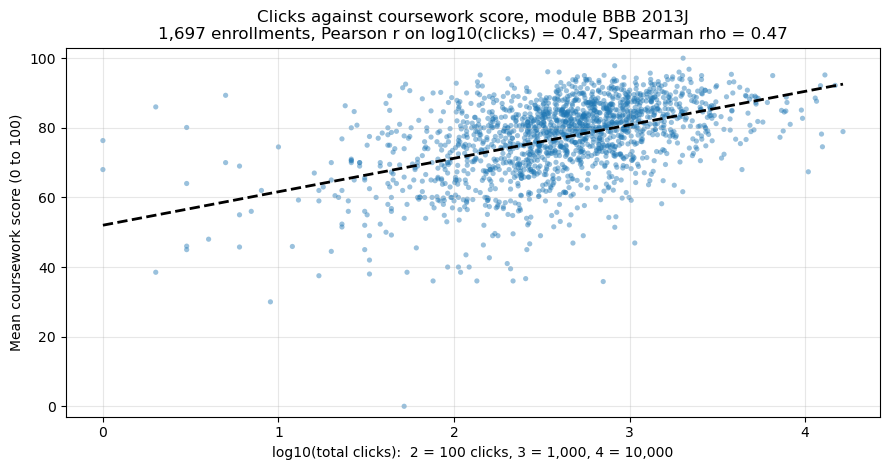

In [ ]:
# EDIT THIS. Either '2013J' or '2014J'. It runs as written.
WHICH_PRESENTATION = '2013J'

# --- nothing below needs editing ---
if WHICH_PRESENTATION not in ('2013J', '2014J'):
    print(f'"{WHICH_PRESENTATION}" is not a presentation in this file. Using 2013J instead.')
    WHICH_PRESENTATION = '2013J'

q = build_panel(WHICH_PRESENTATION)
q_r_raw = q['total_clicks'].corr(q['mean_score'])
q_r_log = np.log10(q['total_clicks']).corr(q['mean_score'])
q_rho   = q['total_clicks'].corr(q['mean_score'], method='spearman')
n_enrolled = int((student_info['code_presentation'] == WHICH_PRESENTATION).sum())

print(f'Presentation          : {WHICH_PRESENTATION}')
print(f'Enrolled              : {n_enrolled:,}')
print(f'In the panel          : {len(q):,}')
print(f'Median clicks         : {q["total_clicks"].median():,.0f}')
print(f'Mean coursework score : {q["mean_score"].mean():.1f}')
print(f'Pearson r, raw clicks : {q_r_raw:.3f}')
print(f'Pearson r, log clicks : {q_r_log:.3f}')
print(f'Spearman rho          : {q_rho:.3f}')
print()
print('Assessments in this presentation:')
print(assessments[assessments['code_presentation'] == WHICH_PRESENTATION]
      [['assessment_type', 'date', 'weight']].to_string(index=False))
print()

# Comparing two years is comparing two estimates, so it needs an interval on the
# difference. Resample each year separately, take the gap, repeat 2,000 times.
a, b = build_panel('2013J'), build_panel('2014J')

def year_stats(df):
    x, y = df['total_clicks'].to_numpy(float), df['mean_score'].to_numpy(float)
    return x, np.log10(x), y

xa, la, ya = year_stats(a)
xb, lb, yb = year_stats(b)
rng = np.random.default_rng(8100)
d_rho, d_log = [], []
for _ in range(2000):
    s1 = rng.integers(0, len(a), len(a))
    s2 = rng.integers(0, len(b), len(b))
    d_rho.append(np.corrcoef(ranks(xa[s1]), ranks(ya[s1]))[0, 1]
                 - np.corrcoef(ranks(xb[s2]), ranks(yb[s2]))[0, 1])
    d_log.append(np.corrcoef(la[s1], ya[s1])[0, 1] - np.corrcoef(lb[s2], yb[s2])[0, 1])
ci_d_rho = np.percentile(d_rho, [2.5, 97.5])
ci_d_log = np.percentile(d_log, [2.5, 97.5])

rho_a = a['total_clicks'].corr(a['mean_score'], method='spearman')
rho_b = b['total_clicks'].corr(b['mean_score'], method='spearman')
log_a = np.log10(a['total_clicks']).corr(a['mean_score'])
log_b = np.log10(b['total_clicks']).corr(b['mean_score'])
print(f'2013J (n = {len(a):,}) against 2014J (n = {len(b):,}):')
print(f'  Spearman rho          {rho_a:.3f} vs {rho_b:.3f}, difference {rho_a - rho_b:.3f} '
      f'[{ci_d_rho[0]:.3f}, {ci_d_rho[1]:.3f}]')
print(f'  Pearson r, log clicks {log_a:.3f} vs {log_b:.3f}, difference {log_a - log_b:.3f} '
      f'[{ci_d_log[0]:.3f}, {ci_d_log[1]:.3f}]')
print('  Neither interval comes near zero, so the two years genuinely differ. That is not')
print('  the same as knowing why: the assessment structure differed too, so year and')
print('  instrument are confounded and this file cannot separate them.')
print()

pooled = pd.concat([build_panel('2013J'), build_panel('2014J')], ignore_index=True)
n_twice = int((pooled['id_student'].value_counts() == 2).sum())
print(f'And if you pooled the two years into one analysis: n = {len(pooled):,}, '
      f'Pearson r on log clicks = '
      f'{np.log10(pooled["total_clicks"]).corr(pooled["mean_score"]):.3f}, '
      f'Spearman rho = '
      f'{pooled["total_clicks"].corr(pooled["mean_score"], method="spearman"):.3f}')
print(f'Section 2a is back: {n_twice} of those {len(pooled):,} rows are a person the other year')
print(f'already counted, so that number does not rest on {len(pooled):,} independent enrollments.')

fig, ax = plt.subplots(figsize=(9, 4.8))
xv = np.log10(q['total_clicks'])
ax.scatter(xv, q['mean_score'], s=14, color='#1f77b4', alpha=0.45, edgecolor='none')
s, i = np.polyfit(xv, q['mean_score'], 1)
xs = np.linspace(xv.min(), xv.max(), 100)
ax.plot(xs, s * xs + i, color='#000000', linewidth=2, linestyle='--')
ax.set_title(f'Clicks against coursework score, module BBB {WHICH_PRESENTATION}\n'
             f'{len(q):,} enrollments, Pearson r on log10(clicks) = {q_r_log:.2f}, '
             f'Spearman rho = {q_rho:.2f}')
ax.set_xlabel('log10(total clicks):  2 = 100 clicks, 3 = 1,000, 4 = 10,000')
ax.set_ylabel('Mean coursework score (0 to 100)')
ax.set_ylim(-3, 103)
plt.tight_layout()
plt.show()

### Let's discuss

1. Running it both ways gives, for each year, a Pearson `r` on log clicks and a Spearman rho.
   Would you describe them as the same finding? The printed interval on the difference is what
   allows an answer other than an impression: the two years differ by more than resampling can
   explain, and the gap is wider on Spearman than the Pearson numbers alone suggested.
2. The mean coursework score differs a good deal between the two years. The assessment table
   printed above is worth reading before explaining why. What changed about the course, and does
   that make the two years comparable at all? The interval is precise about *whether* the years
   differ and silent about *what* differs, because the year and the assessment structure changed
   together.
3. One module, two years, two answers. If they had been pooled into a single analysis, which of
   the two answers would have come out, and would the problem have been visible? The pooled row
   count is also not a count of people. How far off is it, and would that have changed anything?
4. Somebody asks what the relationship between activity and achievement is in module BBB. What
   would you say?

### Your turn 3: which clicks count as engagement?

`total_clicks` counts every click on every kind of resource: the forum, the homepage, quizzes,
PDFs, links out. That is a decision, and decisions can be changed.

`vle.csv` labels every resource with an `activity_type`. You might choose the types you think
belong in an "engagement" indicator and re-run. Two things move: **how many enrollments vanish**
because they never touched what you chose, and the three-column table of correlations. The middle
column is the one to compare against. It is the all-types number recomputed on whoever your
definition left standing, and without it there is no way to tell a better feature from a smaller
sample.

**Run the cell below**, then edit the list and run it again.

In [ ]:
# EDIT THIS LIST. It runs as written; the default keeps every activity type.
ACTIVITY_TYPES = ['forumng', 'homepage', 'quiz', 'subpage', 'resource',
                  'url', 'oucontent', 'glossary', 'oucollaborate', 'sharedsubpage']

# --- nothing below needs editing ---
sites = vle[vle['code_presentation'] == PRESENTATION][['id_site', 'activity_type']]
labeled = vle_log.merge(sites, on='id_site', how='left')

print('Clicks by activity type in this presentation:')
print(labeled.groupby('activity_type')['sum_click'].sum()
              .sort_values(ascending=False).map('{:,}'.format).to_string())
print()

chosen = [t for t in ACTIVITY_TYPES if t in set(labeled['activity_type'].dropna())]
if not chosen:
    print('None of those names matched an activity type. Using all of them instead.')
    chosen = sorted(labeled['activity_type'].dropna().unique().tolist())

kept = labeled[labeled['activity_type'].isin(chosen)]
feature = (kept.groupby('id_student')['sum_click'].sum()
               .rename('chosen_clicks').reset_index())

check = panel[['id_student', 'mean_score', 'total_clicks']].merge(feature, on='id_student',
                                                                 how='inner')
c_raw = check['chosen_clicks'].corr(check['mean_score'])
c_log = np.log10(check['chosen_clicks']).corr(check['mean_score'])
c_rho = check['chosen_clicks'].corr(check['mean_score'], method='spearman')

# The narrower definition also removes people, so a comparison against the full-panel
# number confuses two changes at once. Recompute the all-types number on whoever is left.
same_raw = check['total_clicks'].corr(check['mean_score'])
same_log = np.log10(check['total_clicks']).corr(check['mean_score'])
same_rho = check['total_clicks'].corr(check['mean_score'], method='spearman')

print(f'Counting: {", ".join(chosen)}')
print(f'Clicks kept   : {kept["sum_click"].sum():,} of {labeled["sum_click"].sum():,}')
print(f'Students left : {len(check):,} of {len(panel):,}   '
      f'({len(panel) - len(check)} vanished, having never touched these resources)')
print()
print('                         your types   all types,      all types,')
print('                                      same students   all 1,697')
print(f'Pearson r, raw counts        {c_raw:.3f}         {same_raw:.3f}          {r_raw:.3f}')
print(f'Pearson r, log counts        {c_log:.3f}         {same_log:.3f}          {r_log:.3f}')
print(f'Spearman rho                 {c_rho:.3f}         {same_rho:.3f}          {rho:.3f}')
print()
print('The middle column is the one to read across, rather than the right one. The right column is computed on')
print('people your definition just removed, so a gap against it mixes up two different')
print('changes: what you counted, and who you were still able to count.')

Clicks by activity type in this presentation:
activity_type
forumng          702,326
homepage         344,964
quiz             118,688
subpage           81,487
resource          54,615
url               38,575
oucontent         34,877
glossary           1,916
oucollaborate      1,144
sharedsubpage         64



Counting: forumng, homepage, quiz, subpage, resource, url, oucontent, glossary, oucollaborate, sharedsubpage
Clicks kept   : 1,378,656 of 1,378,656
Students left : 1,697 of 1,697   (0 vanished, having never touched these resources)

                         your types   all types,      all types,
                                      same students   all 1,697
Pearson r, raw counts        0.258         0.258          0.258
Pearson r, log counts        0.473         0.473          0.473
Spearman rho                 0.466         0.466          0.466

The middle column is the one to read across, rather than the right one. The right column is computed on
people your definition just removed, so a gap against it mixes up two different
changes: what you counted, and who you were still able to count.


**Let's discuss.** A definition changed, not a fact about any student, and the number a
dashboard would report about them moved.

It is also worth noticing how easy it was to compare the wrong things. The obvious comparison is
your number against the headline 0.473, and that comparison is contaminated: your definition
removed students, so any difference is partly the feature and partly the sample. The middle column
is the cleaner comparison, and having to build it is a small version of a problem that runs
through the field. Whenever a new feature is announced as better than an old one, it is worth
asking whether both were measured on the same people.

Then the harder question. Every student who "vanished" did not stop existing; they stopped being
measurable by your definition. It may be useful to write one sentence naming the candidate feature
you would be willing to stand behind if the student it describes were reading it, and one sentence
about what is owed to the students your definition erased.

## Appendix: expected numbers for the Your turn cells

Each one is worth trying first. These are here so that nobody gets stuck, and so that you can
check your reading of the output.

### Your turn 1: three cleaning decisions

The baseline, and three worth trying:

```python
INCLUDE_PRE_START_CLICKS = True  ; MIN_SUBMISSIONS = 1 ; KEEP_WITHDRAWN = True    # n = 1,697, Pearson 0.258 raw / 0.473 log, Spearman 0.466
INCLUDE_PRE_START_CLICKS = False ; MIN_SUBMISSIONS = 1 ; KEEP_WITHDRAWN = True    # n = 1,695, Pearson 0.256 raw / 0.462 log, Spearman 0.463
INCLUDE_PRE_START_CLICKS = True  ; MIN_SUBMISSIONS = 1 ; KEEP_WITHDRAWN = False   # n = 1,494, Pearson 0.260 raw / 0.471 log, Spearman 0.465
INCLUDE_PRE_START_CLICKS = True  ; MIN_SUBMISSIONS = 3 ; KEEP_WITHDRAWN = True    # n = 1,512, Pearson 0.232 raw / 0.382 log, Spearman 0.396
```

What is worth noticing: the pre-start switch is nearly free, costing two enrollments and moving
the raw Pearson by two thousandths and the log Pearson by about a hundredth. Dropping withdrawn
enrollments costs 203 rows and barely moves anything, which is its own result: by the time an
enrollment has both clicks and submitted coursework, the withdrawn label is not doing much work.
Requiring three submissions costs 185 rows and takes the log Pearson from 0.473 to 0.382, about a
fifth of it, and the Spearman from 0.466 to 0.396, about a seventh. It removes the enrollments
whose short records were carrying the low end of the relationship.

That last row is worth holding against the interval Section 7 printed, roughly 0.43 to 0.51 on the
log Pearson. Requiring three submissions moves the estimate outside its own interval, which is one
way to tell a different population from sampling wobble. The other two switches move it by less
than the interval is wide, and the rank correlation, the number least sensitive to the shape you
assume, is the last to move: 0.466 baseline against 0.463 and 0.465. Only the submissions rule
moves it more than a rounding error.

Three defensible decisions produce four different papers, and usually only one of them gets
reported. No single setting is the right one.

### Your turn 2: the other year

```python
WHICH_PRESENTATION = '2013J'   # n = 1,697, Pearson 0.258 raw / 0.473 log, Spearman 0.466, mean score 77.1
WHICH_PRESENTATION = '2014J'   # n = 1,788, Pearson 0.144 raw / 0.195 log, Spearman 0.106, mean score 64.3
```

What is worth noticing: the relationship in 2014J is well under half as strong on the log scale,
and the mean coursework score is about thirteen points lower. The assessment table accounts for a
good deal of it. 2013J ran six tutor-marked and five computer-marked assignments; 2014J ran five
tutor-marked assignments and one of those was weighted zero. Different instruments, different
difficulty, different scores.

The Spearman pair makes the gap between the years look wider rather than narrower: 0.47 against
0.11. The cell prints an interval on that gap rather than leaving you to eyeball it, because two
numbers being different on the page is not the same as two numbers being different. The difference
in Spearman is about 0.36 with a 95 percent interval of roughly 0.30 to 0.42, and the difference
in the log Pearson is about 0.28 with an interval of roughly 0.21 to 0.35. Neither interval is
close to zero, so the years do differ.

That settles *whether* and says nothing about *why*. The year changed and the assessment structure
changed at the same time, so the two cannot be separated in this file. An interval is precise
about sampling and silent about confounding, and confusing the two is one of the more common ways
a careful-looking result goes wrong.

Pool the two years into one analysis and the Pearson on log clicks comes out near 0.22 and the
Spearman near 0.15, lower than 2013J, higher than 2014J, and a description of neither. On top of
that, 25 of the 3,485 pooled rows are somebody the other year already counted, so it is not 3,485
independent enrollments either. That is the argument for keeping the presentations apart, and it
is why "we analyzed module BBB" is not an adequate methods sentence.

### Your turn 3: which clicks count

```python
ACTIVITY_TYPES = ['forumng']                       # log Pearson 0.402, Spearman 0.419,  76 enrollments vanish
ACTIVITY_TYPES = ['quiz']                          # log Pearson 0.393, Spearman 0.317, 107 enrollments vanish
ACTIVITY_TYPES = ['oucontent']                     # log Pearson 0.411, Spearman 0.390, 201 enrollments vanish
ACTIVITY_TYPES = ['forumng', 'oucontent', 'quiz']  # log Pearson 0.475, Spearman 0.465,  19 enrollments vanish
```

What is worth noticing, and the order matters. Compare each of those against the **middle** column
the cell prints, the all-types number recomputed on whoever survived your definition, rather than
against the 0.473 from the full panel. On that comparison no single activity type beats counting
everything: forum 0.402 against 0.448 on the same 1,621 people, quiz 0.393 against 0.428 on the
same 1,590, course material 0.411 against 0.442 on the same 1,496. The three combined are the one
candidate that does beat it, 0.475 against 0.463 on the same 1,678, and the careful way to
describe that is "slightly, and on nearly everybody" rather than "better".

The narrower the definition, the more enrollments it erases. `oucontent`, the actual course
material, loses 201 enrollments with no recorded click on it in a form the log recognized. A
feature that quietly removes two hundred people is not a neutral measurement choice, and it is the
reason the middle column exists: without it, a feature could look better simply by discarding the
people it fits worst.

It is also worth noticing that `quiz` clicks look competitive with forum clicks on Pearson and
clearly worse on Spearman, 0.32 against 0.42. The two statistics rank these candidate features differently, which
is worth a minute: whichever one gets reported first is a choice, made either before or after
seeing the numbers. Then there is the question of whether "clicking a quiz" is an indicator of
engagement or an indicator of *being assessed*, and whether a dashboard built on quiz clicks is
measuring the student or the calendar.